In [4]:
import pandas as pd

df_dow30 = pd.read_csv('/content/dow30_daily_returns_2021_2026.csv')
df_rv_filled = pd.read_csv('/content/merged_rv_data_filled.csv')
df_iv_filled = pd.read_csv('/content/merged_iv_data_filled.csv')

print('--- dow30_daily_returns_2021_2026.csv ---')
display(df_dow30.head())

print('\n--- merged_rv_data_filled.csv ---')
display(df_rv_filled.head())

print('\n--- merged_iv_data_filled.csv ---')
display(df_iv_filled.head())

--- dow30_daily_returns_2021_2026.csv ---


,Date,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,...,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,V,WMT
0,2021-01-27,-0.007684,-0.029157,-0.028126,-0.017736,-0.039741,-0.035148,-0.006541,0.009722,-0.012981,...,0.060813,-0.039626,0.002453,-0.030200,-0.035389,-0.029295,-0.029495,-0.025455,-0.034850,-0.024879
1,2021-01-28,-0.034985,-0.013184,0.001559,0.042773,0.016492,0.020539,0.007652,-0.007877,0.009297,...,-0.017305,0.011029,0.025891,0.028240,0.015423,0.003584,0.015496,0.004353,0.016669,-0.000626
2,2021-01-29,-0.037421,-0.025509,-0.009705,-0.022779,-0.015413,-0.008137,-0.004150,-0.016762,-0.042911,...,-0.042307,-0.010909,-0.029172,-0.008387,-0.016493,-0.026429,-0.013515,-0.011197,-0.025073,-0.022678
3,2021-02-01,0.016520,-0.004142,0.042630,0.006623,0.008497,0.010282,0.012857,0.018394,0.014202,...,-0.005465,0.003763,0.033152,0.015869,0.005928,0.014013,0.001259,-0.008585,0.026442,-0.008684
4,2021-02-02,0.006337,0.000249,0.011104,0.031359,0.026042,0.042118,0.025125,0.009471,0.007522,...,0.001832,0.005300,-0.000584,0.028590,-0.001396,0.011722,0.014132,0.004053,0.021426,0.010770



--- merged_rv_data_filled.csv ---


,Date,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,...,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,V,WMT
0,2021-01-26,29.53,20.85,21.73,26.58,25.13,23.51,20.41,16.56,25.63,...,19.39,18.83,19.78,20.06,15.14,21.39,24.34,13.12,20.24,13.72
1,2021-01-27,29.49,21.90,21.90,27.81,26.17,24.38,20.53,17.52,26.59,...,22.59,20.61,21.68,20.31,17.38,22.39,24.84,14.85,20.68,14.82
2,2021-01-28,29.78,34.76,21.97,28.53,25.88,24.92,20.54,17.77,26.65,...,22.85,20.87,22.45,21.37,18.52,22.51,25.67,15.55,21.01,14.95
3,2021-01-29,31.28,35.11,21.91,28.73,27.13,26.28,21.16,18.02,26.84,...,24.74,21.34,22.91,21.66,18.76,22.96,26.08,15.53,23.27,15.70
4,2021-02-01,31.72,35.26,22.98,28.83,27.26,26.57,21.56,18.30,27.50,...,24.95,21.12,24.42,21.99,18.69,23.02,25.94,15.80,23.44,15.94



--- merged_iv_data_filled.csv ---


,Date,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,...,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,V,WMT
0,2021-01-26,48.21,27.84,40.08,34.13,50.82,35.00,42.04,32.36,39.50,...,25.67,25.34,34.08,28.98,21.09,26.24,29.56,18.38,29.36,28.46
1,2021-01-27,49.12,33.28,46.18,39.85,54.21,42.33,46.51,35.00,43.58,...,31.38,28.98,35.27,36.33,26.70,33.50,33.56,21.04,33.67,33.76
2,2021-01-28,42.39,37.44,42.19,39.07,50.82,36.56,44.49,33.82,37.46,...,28.03,29.42,30.48,30.93,21.79,28.37,30.53,19.81,31.04,33.20
3,2021-01-29,44.55,35.46,43.02,38.45,52.25,35.95,45.27,36.22,40.38,...,30.35,29.09,33.59,32.76,23.65,33.76,31.94,21.41,33.12,33.62
4,2021-02-01,38.48,33.30,40.35,35.47,49.12,32.86,42.25,34.44,38.33,...,29.04,29.64,30.07,31.79,21.70,29.20,29.94,21.45,29.20,33.44


## 测试GHAR

In [3]:
import argparse
import os
from os.path import join

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.covariance import GraphicalLassoCV
import torch # Added for device selection

# ==================== Device Configuration ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training device: {device}")


# ==================== Configuration ====================
parser = argparse.ArgumentParser()
parser.add_argument("--window", type=int, default=22, help="forward-looking period")
parser.add_argument("--horizon", type=int, default=1, help="forecasting horizon")
parser.add_argument("--model_name", type=str, default='GHAR', help="model name")
parser.add_argument("--adj_name", type=str, default='iden+glasso',
                    help="adj choices: iden, glasso, or iden+glasso")

# 这里改成包含两个新 CSV 的目录（/content）
parser.add_argument("--data_dir", type=str, default=r'/content',
                   help="data directory containing the CSV files")

parser.add_argument("--version", type=str, default='Forecast_Vol_SEP100', help="version name")

opt = parser.parse_args(args=[])

print("="*80)
print("GHAR Model Configuration")
print("="*80)
print(f"Window: {opt.window}")
print(f"Horizon: {opt.horizon}")
print(f"Model: {opt.model_name}")
print(f"Adjacency: {opt.adj_name}")
print(f"Data directory: {opt.data_dir}\n")

this_version = '_'.join([
    opt.version,
    opt.model_name,
    opt.adj_name,
    'W' + str(opt.window),
    'H' + str(opt.horizon)
])

result_path = join(opt.data_dir, 'GHAR_Results', this_version)
os.makedirs(result_path, exist_ok=True)
print(f"Results will be saved to: {result_path}\n")

# ==================== Data Loading Functions ====================
def load_volatility_data():
    """加载 realized volatility 数据（替换原来的 EWMA）"""
    # 这里改成新的 rv 文件名
    vol_file = join(opt.data_dir, 'merged_rv_data_filled.csv')
    print(f"Loading volatility from: {vol_file}")

    vol_df = pd.read_csv(vol_file, index_col='Date', parse_dates=True)
    vol_df = vol_df.sort_index(axis=1)
    vol_df = vol_df.dropna(how='all')

    print(f"✓ Loaded volatility: {vol_df.shape}")
    print(f"  Date range: {vol_df.index[0]} to {vol_df.index[-1]}")
    print(f"  Stocks: {len(vol_df.columns)}")
    return vol_df


def load_returns_data():
    """加载对数收益率数据（替换原来的 2011–2021 文件）"""
    # 这里改成新的 ret 文件名
    ret_file = join(opt.data_dir, 'dow30_daily_returns_2021_2026.csv')
    print(f"Loading returns from: {ret_file}")

    ret_df = pd.read_csv(ret_file, index_col='Date', parse_dates=True)
    ret_df = ret_df.sort_index(axis=1)
    ret_df = ret_df.dropna(how='all')

    print(f"✓ Loaded returns: {ret_df.shape}")
    print(f"  Date range: {ret_df.index[0]} to {ret_df.index[-1]}")
    print(f"  Stocks: {len(ret_df.columns)}")
    return ret_df

# 下面所有函数（compute_future_volatility、preprocess_HAR、GLASSO_Precision、
# preprocess_adj_l、df2arr、Train、connect_pred，以及 main 部分）逻辑可以保持不变、
# 直接复用你原来的代码即可。

def compute_future_volatility(vol_df, horizon=1):
    """
    计算未来波动率作为预测目标
    horizon=1: 向前移动1天
    horizon>1: 计算未来'horizon'天的平均值
    """
    if horizon == 1:
        target_vol = vol_df.shift(-1)
    else:
        target_vol = 0
        for h in range(1, horizon + 1):
            target_vol += vol_df.shift(-h)
        target_vol = target_vol / horizon
    return target_vol

# ==================== HAR Feature Construction ====================
def preprocess_HAR(feature_df, target_df):
    """
    构建HAR（异构自回归）特征
    使用1天、5天、22天的滞后期（日、周、月）
    """
    subdf_l = []
    all_assets = list(target_df.columns)
    all_assets.sort()

    # HAR滞后期：1天（日）、5天（周）、22天（月）
    har_lags = [1, 5, 22]

    print(f"\nConstructing HAR features for {len(all_assets)} assets...")

    # 为每个资产构建HAR特征
    for i, target_asset in enumerate(all_assets):
        if (i + 1) % 20 == 0:
            print(f"  Progress: {i + 1}/{len(all_assets)} assets")

        # 创建子数据框
        subdf = pd.DataFrame()
        subdf['Target'] = target_df[target_asset].copy()  # 预测目标
        subdf['Date'] = target_df.index  # 日期
        subdf['Ticker'] = target_asset  # 股票代码

        # 构建HAR特征
        indpt_df_l = []
        for lag in har_lags:
            # 计算过去'lag'天的平均值
            tmp_indpdt_df = 0
            for il in range(1, 1 + lag):
                tmp_indpdt_df += feature_df[target_asset].shift(il)

            indpt_df_l.append(tmp_indpdt_df / lag)

        # 创建特征数据框
        explain_df = pd.concat(indpt_df_l, axis=1)
        explain_df.columns = ['vol+lag%d' % i for i in har_lags]  # 特征列名

        # 合并目标和特征
        subdf = pd.merge(subdf, explain_df, left_index=True, right_index=True)

        # 清理无穷大和NaN值
        subdf.replace([np.inf, -np.inf], np.nan, inplace=True)
        subdf.dropna(inplace=True)

        subdf_l.append(subdf)

    # 合并所有资产的数据
    df = pd.concat(subdf_l)
    df.reset_index(drop=True, inplace=True)

    # 按日期创建字典
    date_l = list(set(df['Date'].tolist()))
    date_l.sort()

    subdf_dic = {}
    for date in date_l:
        subdf = df[df['Date'] == date]
        subdf_dic[date] = subdf

    print(f'✓ HAR feature preparation complete!')
    print(f'  Total dates: {len(date_l)}')
    print(f'  Date range: {date_l[0]} to {date_l[-1]}')

    return subdf_dic, date_l


# ==================== Graph Construction ====================
def GLASSO_Precision(subret):
    """
    使用图拉索计算精度矩阵并构建邻接矩阵
    """
    n = subret.shape[1]  # 资产数量
    tickers = subret.columns

    # 使用交叉验证拟合图拉索
    try:
        cov = GraphicalLassoCV(cv=3, max_iter=100).fit(subret)
        print(f'  Alpha in GLASSO: {cov.alpha_:.4f}')  # 正则化参数

        # 从精度矩阵中提取非零元素
        corr = cov.precision_ != 0
        print(f'  Sparsity of Adj: {corr.mean():.4f}')  # 邻接矩阵稀疏度

        # 移除对角线（自环）
        corr_adj = corr - np.identity(n)

        # 对称归一化：D^(-1/2) * A * D^(-1/2)
        d_sqrt_inv = np.diag(np.sqrt(1 / (corr_adj.sum(1) + 1e-8)))
        adj_df = pd.DataFrame(
            np.dot(np.dot(d_sqrt_inv, corr_adj), d_sqrt_inv),
            columns=tickers,
            index=tickers
        )
    except Exception as e:
        print(f"  Warning: GLASSO failed ({e}), using identity matrix instead")
        # 如果图拉索失败，使用单位矩阵
        adj_df = pd.DataFrame(np.identity(n), index=tickers, columns=tickers)

    return adj_df


def preprocess_adj_l(date_l, subdf_dic, adj_df_l):
    """
    Apply graph convolution using adjacency matrices
    修复：确保邻接矩阵和数据的股票列表对齐
    """
    new_subdf_l = []

    for date in date_l:
        if date not in subdf_dic:
            continue

        subdf = subdf_dic[date]

        # 获取当前日期的股票列表
        current_tickers = subdf['Ticker'].unique()

        tmp_subdf_l = []
        clms = [i for i in subdf.columns if 'lag' in i]

        # Apply each adjacency matrix
        for k, adj_df in enumerate(adj_df_l):
            # ===== 关键修复：只使用当前日期存在的股票 =====
            # 重新索引邻接矩阵，只保留current_tickers
            adj_df_aligned = adj_df.reindex(index=current_tickers, columns=current_tickers, fill_value=0)

            # 确保subdf的顺序与adj_df_aligned一致
            subdf_sorted = subdf.set_index('Ticker').loc[current_tickers].reset_index()

            # 现在维度应该对齐了
            # adj_df_aligned: (n_current, n_current)
            # subdf_sorted[clms]: (n_current, n_features)
            try:
                conv_result = np.dot(adj_df_aligned.values, subdf_sorted[clms].values)
                tmp_subdf = pd.DataFrame(
                    conv_result,
                    columns=['sec' + str(k) + i for i in clms],
                    index=subdf_sorted.index
                )
            except ValueError as e:
                print(f"  Error at date {date}: {e}")
                print(f"    adj shape: {adj_df_aligned.shape}")
                print(f"    data shape: {subdf_sorted[clms].shape}")
                print(f"    current_tickers: {len(current_tickers)}")
                # 如果出错，使用原始数据（相当于跳过图卷积）
                tmp_subdf = pd.DataFrame(
                    subdf_sorted[clms].values,
                    columns=['sec' + str(k) + i for i in clms],
                    index=subdf_sorted.index
                )

            tmp_subdf_l.append(tmp_subdf)

        # 使用排序后的subdf
        new_subdf = pd.concat([subdf_sorted[['Target', 'Date', 'Ticker']]] + tmp_subdf_l, axis=1)
        new_subdf_l.append(new_subdf)

    if len(new_subdf_l) == 0:
        print("  Warning: No valid data to transform")
        return pd.DataFrame()

    df = pd.concat(new_subdf_l)
    df.reset_index(drop=True, inplace=True)
    print('✓ Graph transformation complete!')

    return df

def df2arr(df, vars_l):
    """将数据框转换为sklearn所需的数组格式"""
    all_inputs = df[vars_l].values  # 特征矩阵
    all_targets = df[['Target']].values  # 目标向量
    return all_inputs, all_targets


# ==================== Training Function ====================
def Train(ret_df, vol_df, subdf_dic, date, date_l):
    """为特定日期训练GHAR模型"""
    timestamp = date_l.index(date)

    # 定义训练窗口
    s_p = max(timestamp - 1000, 0)  # 训练开始位置（最多1000天历史）
    f_p = min(timestamp + opt.window, len(date_l) - 1)  # 测试结束位置

    s_date = date_l[s_p]
    f_date = date_l[f_p]

    print(f"\n{'='*80}")
    print(f"Training for date: {date}")
    print(f"  Training period: {s_date} to {date}")
    print(f"  Testing period: {date} to {f_date}")
    print(f"{'='*80}")

    # 准备训练数据
    subret = ret_df[ret_df.index < date]  # 训练期收益率
    subret = subret[subret.index >= s_date]
    subret = subret.dropna(axis=1, how='all')  # 移除全为NaN的股票

    subdata = vol_df[vol_df.index < date]  # 训练期波动率
    subdata = subdata[subdata.index >= s_date]

    # ===== 关键修复：确保使用相同的股票列表 =====
    # 只保留在收益率数据中有效的股票
    valid_tickers = subret.columns
    print(f"  Valid tickers in returns: {len(valid_tickers)}")

    # 从subdf_dic中筛选出只包含valid_tickers的数据
    filtered_subdf_dic = {}
    for d in date_l[s_p:f_p + 1]:
        if d in subdf_dic:
            subdf = subdf_dic[d]
            # 只保留valid_tickers中的股票
            filtered_subdf = subdf[subdf['Ticker'].isin(valid_tickers)]
            if len(filtered_subdf) > 0:
                filtered_subdf_dic[d] = filtered_subdf

    if len(filtered_subdf_dic) == 0:
        print("  ⚠ Skipping: no valid data after filtering")
        return None

    n = len(valid_tickers)
    print(f"  Number of assets: {n}")
    print(f"  Training samples: {len(subret)}")

    # 构建邻接矩阵 - 使用valid_tickers
    adj_name_l = opt.adj_name.split('+')
    adj_df_l = []

    for adj_name in adj_name_l:
        print(f"\nConstructing adjacency matrix: {adj_name}")
        if adj_name == 'iden':
            # 单位矩阵（标准HAR模型）
            adj_df = pd.DataFrame(np.identity(n), index=valid_tickers, columns=valid_tickers)
            print("  Using identity matrix (standard HAR)")
        elif adj_name == 'glasso':
            # 图拉索邻接矩阵
            adj_df = GLASSO_Precision(subret)
            # 确保邻接矩阵的列顺序与valid_tickers一致
            adj_df = adj_df.reindex(index=valid_tickers, columns=valid_tickers, fill_value=0)
        else:
            # 零矩阵
            adj_df = pd.DataFrame(np.zeros((n, n)), index=valid_tickers, columns=valid_tickers)

        # 验证邻接矩阵维度
        print(f"  Adjacency matrix shape: {adj_df.shape}")
        adj_df_l.append(adj_df)

    # 应用图变换 - 使用filtered_subdf_dic
    df = preprocess_adj_l(list(filtered_subdf_dic.keys()), filtered_subdf_dic, adj_df_l)

    vars_l = [i for i in df.columns if 'lag' in i]  # 获取所有特征变量

    # 分割训练/测试集
    train_df = df[df['Date'] >= s_date]
    train_df = train_df[train_df['Date'] < date]

    test_df = df[df['Date'] >= date]
    test_df = test_df[test_df['Date'] < f_date]

    print(f"\n  Training set: {len(train_df)} samples")
    print(f"  Test set: {len(test_df)} samples")

    if len(train_df) == 0 or len(test_df) == 0:
        print("  ⚠ Skipping: insufficient data")
        return None

    # 准备数组格式数据
    train_x, train_y = df2arr(train_df, vars_l)
    test_x, test_y = df2arr(test_df, vars_l)

    # 训练线性回归模型
    model = LinearRegression()
    model.fit(train_x, train_y)

    print(f"\n  Model coefficients shape: {model.coef_.shape}")
    print(f"  R² on training: {model.score(train_x, train_y):.4f}")

    # 进行预测
    test_pred_df = test_df[['Ticker', 'Date']].copy()
    test_pred_df['Pred_GHAR'] = model.predict(test_x)
    test_pred_df = test_pred_df.pivot(index='Date', columns='Ticker', values='Pred_GHAR')

    test_pred_df.columns = list(test_pred_df.columns)
    test_pred_df.index = list(test_pred_df.index)

    print(f'\n  Before adjustment - Min prediction: {test_pred_df.min().min():.6f}')

    # 调整负预测值为训练数据的最小值
    for clm in test_pred_df.columns:
        clm_pred_df = test_pred_df[clm]
        clm_train_df = train_df[train_df['Ticker'] == clm]['Target']
        if len(clm_train_df) > 0:
            min_val = max(clm_train_df.min(), 1e-6)  # 确保为正值
            clm_pred_df[clm_pred_df <= 0] = min_val
            test_pred_df[clm] = clm_pred_df

    print(f'  After adjustment - Min prediction: {test_pred_df.min().min():.6f}')

    # 保存预测结果
    pred_filename = f'Pred_{str(date)[:10]}.csv'
    test_pred_df.to_csv(join(result_path, pred_filename))
    print(f"  ✓ Saved predictions to {pred_filename}")

    return test_pred_df

# ==================== Connect Predictions ====================
def connect_pred():
    """连接所有预测文件"""
    print("\n" + "="*80)
    print("Connecting all predictions...")
    print("="*80)

    # 获取所有预测文件
    files_l = os.listdir(result_path)
    pred_files = [i for i in files_l if 'Pred_' in i and i.endswith('.csv')]
    pred_files.sort()

    print(f"Found {len(pred_files)} prediction files")

    if len(pred_files) == 0:
        print("No prediction files found!")
        return None

    # 读取并合并所有预测文件
    test_pred_df_l = []
    for i in pred_files:
        test_pred_df = pd.read_csv(join(result_path, i), index_col=0, parse_dates=True)
        test_pred_df_l.append(test_pred_df)

    # 连接所有预测结果
    test_pred_df = pd.concat(test_pred_df_l)
    test_pred_df = test_pred_df.sort_index()  # 按日期排序

    print(f"\nFinal prediction dataframe:")
    print(f"  Shape: {test_pred_df.shape}")
    print(f"  Date range: {test_pred_df.index[0]} to {test_pred_df.index[-1]}")

    # 保存合并后的预测结果
    sum_path = join(opt.data_dir, 'GHAR_Results_Summary')
    os.makedirs(sum_path, exist_ok=True)

    output_file = join(sum_path, this_version + '_predictions.csv')
    test_pred_df.to_csv(output_file)
    print(f"\n✓ Saved final predictions to: {output_file}")

    return test_pred_df


# ==================== Main Execution ====================
if __name__ == '__main__':
    print("\n" + "="*80)
    print("GHAR Model Training for SEP100 Dataset")
    print("="*80)

    # 步骤1：加载数据
    print("\nStep 1: Loading data...")
    vol_df_raw = load_volatility_data()  # 加载波动率数据
    ret_df_raw = load_returns_data()     # 加载收益率数据

    # ===== 新增：过滤掉指定的股票 =====
    print("\nStep 1.5: Filtering out stocks with excessive NaN values...")

    # 定义要排除的股票列表（基于NaN分析结果）
    stocks_to_exclude = [] # ['ABBV', 'BRK.B', 'DOW', 'FB', 'KHC', 'PYPL']

    print(f"  Stocks to exclude: {stocks_to_exclude}")
    print(f"  Original data shape: vol={vol_df_raw.shape}, ret={ret_df_raw.shape}")

    # 过滤掉这些股票
    vol_df = vol_df_raw.drop(columns=stocks_to_exclude, errors='ignore')
    ret_df = ret_df_raw.drop(columns=stocks_to_exclude, errors='ignore')

    print(f"  After filtering: vol={vol_df.shape}, ret={ret_df.shape}")
    print(f"  Remaining stocks: {len(vol_df.columns)}")
    print(f"  ✓ Filtering complete!")

    # 步骤2：计算未来波动率目标
    print(f"\nStep 2: Computing future volatility (horizon={opt.horizon})...")
    target_vol_df = compute_future_volatility(vol_df, opt.horizon)
    target_vol_df = target_vol_df.dropna(how='all')
    print(f"✓ Target volatility shape: {target_vol_df.shape}")

    # 步骤3：构建HAR特征
    print("\nStep 3: Constructing HAR features...")
    subdf_dic, date_l = preprocess_HAR(vol_df, target_vol_df)

    # 步骤4：设置训练计划
    print(f"\nStep 4: Setting up training schedule...")
    start_date = pd.Timestamp('2011-07-01')  # 训练开始日期

    # 找到第一个 >= start_date 的日期
    valid_dates = [d for d in date_l if pd.Timestamp(d) >= start_date]
    if len(valid_dates) == 0:
        print("Error: No dates found after 2011-07-01")
        exit(1)

    idx = date_l.index(valid_dates[0])
    print(f"  Starting from: {date_l[idx]}")

    # 按窗口大小间隔选择训练日期
    training_dates = date_l[idx::opt.window]
    print(f"  Training will run for {len(training_dates)} dates")
    print(f"  From {training_dates[0]} to {training_dates[-1]}")
    print(f"  Window size: {opt.window} days")

    # 步骤5：训练模型
    print("\n" + "="*80)
    print("Step 5: Starting model training...")
    print("="*80)

    for i, date in enumerate(training_dates):
        print(f"\n[{i+1}/{len(training_dates)}] " + "=" * 60)
        Train(ret_df, vol_df, subdf_dic, date, date_l)

    # 步骤6：连接所有预测结果
    print("\nStep 6: Concatenating predictions...")
    final_predictions = connect_pred()

    print("\n" + "="*80)
    print("GHAR TRAINING COMPLETE!")
    print("="*80)
    print(f"\nResults saved in: {result_path}")
    print(f"Summary saved in: {join(opt.data_dir, 'GHAR_Results_Summary')}")

Training device: cuda
GHAR Model Configuration
Window: 22
Horizon: 1
Model: GHAR
Adjacency: iden+glasso
Data directory: /content

Results will be saved to: /content/GHAR_Results/Forecast_Vol_SEP100_GHAR_iden+glasso_W22_H1


GHAR Model Training for SEP100 Dataset

Step 1: Loading data...
Loading volatility from: /content/merged_rv_data_filled.csv
✓ Loaded volatility: (1256, 30)
  Date range: 2021-01-26 00:00:00 to 2026-01-26 00:00:00
  Stocks: 30
Loading returns from: /content/dow30_daily_returns_2021_2026.csv
✓ Loaded returns: (1254, 30)
  Date range: 2021-01-27 00:00:00 to 2026-01-23 00:00:00
  Stocks: 30

Step 1.5: Filtering out stocks with excessive NaN values...
  Stocks to exclude: []
  Original data shape: vol=(1256, 30), ret=(1254, 30)
  After filtering: vol=(1256, 30), ret=(1254, 30)
  Remaining stocks: 30
  ✓ Filtering complete!

Step 2: Computing future volatility (horizon=1)...
✓ Target volatility shape: (1255, 30)

Step 3: Constructing HAR features...

Constructing HAR feat

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Alpha in GLASSO: 0.0001
  Sparsity of Adj: 0.2444
  Adjacency matrix shape: (30, 30)
✓ Graph transformation complete!

  Training set: 660 samples
  Test set: 660 samples

  Model coefficients shape: (1, 6)
  R² on training: 0.9564

  Before adjustment - Min prediction: 10.651077
  After adjustment - Min prediction: 10.651077
  ✓ Saved predictions to Pred_2021-03-30.csv

[3/57] ============================================================

Training for date: 2021-04-30 00:00:00
  Training period: 2021-02-26 00:00:00 to 2021-04-30 00:00:00
  Testing period: 2021-04-30 00:00:00 to 2021-06-02 00:00:00
  Valid tickers in returns: 30
  Number of assets: 30
  Training samples: 44

Constructing adjacency matrix: iden
  Using identity matrix (standard HAR)
  Adjacency matrix shape: (30, 30)

Constructing adjacency matrix: glasso


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_graph_lasso.py:168: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_graph_lasso.py:169: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Alpha in GLASSO: 0.0001
  Sparsity of Adj: 0.2733
  Adjacency matrix shape: (30, 30)
✓ Graph transformation complete!

  Training set: 1320 samples
  Test set: 660 samples

  Model coefficients shape: (1, 6)
  R² on training: 0.9623

  Before adjustment - Min prediction: 10.370043
  After adjustment - Min prediction: 10.370043
  ✓ Saved predictions to Pred_2021-04-30.csv

[4/57] ============================================================

Training for date: 2021-06-02 00:00:00
  Training period: 2021-02-26 00:00:00 to 2021-06-02 00:00:00
  Testing period: 2021-06-02 00:00:00 to 2021-07-02 00:00:00
  Valid tickers in returns: 30
  Number of assets: 30
  Training samples: 66

Constructing adjacency matrix: iden
  Using identity matrix (standard HAR)
  Adjacency matrix shape: (30, 30)

Constructing adjacency matrix: glasso


...

  Alpha in GLASSO: 0.0001
  Sparsity of Adj: 0.3556
  Adjacency matrix shape: (30, 30)
✓ Graph transformation complete!

  Training set: 30000 samples
  Test set: 660 samples

  Model coefficients shape: (1, 6)
  R² on training: 0.9616

  Before adjustment - Min prediction: 13.069666
  After adjustment - Min prediction: 13.069666
  ✓ Saved predictions to Pred_2025-11-18.csv

[56/57] ============================================================

Training for date: 2025-12-19 00:00:00
  Training period: 2021-12-27 00:00:00 to 2025-12-19 00:00:00
  Testing period: 2025-12-19 00:00:00 to 2026-01-23 00:00:00
  Valid tickers in returns: 30
  Number of assets: 30
  Training samples: 1000

Constructing adjacency matrix: iden
  Using identity matrix (standard HAR)
  Adjacency matrix shape: (30, 30)

Constructing adjacency matrix: glasso


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Alpha in GLASSO: 0.0001
  Sparsity of Adj: 0.3578
  Adjacency matrix shape: (30, 30)
✓ Graph transformation complete!

  Training set: 30000 samples
  Test set: 660 samples

  Model coefficients shape: (1, 6)
  R² on training: 0.9618

  Before adjustment - Min prediction: 11.465003
  After adjustment - Min prediction: 11.465003
  ✓ Saved predictions to Pred_2025-12-19.csv

[57/57] ============================================================

Training for date: 2026-01-23 00:00:00
  Training period: 2022-01-27 00:00:00 to 2026-01-23 00:00:00
  Testing period: 2026-01-23 00:00:00 to 2026-01-23 00:00:00
  Valid tickers in returns: 30
  Number of assets: 30
  Training samples: 1000

Constructing adjacency matrix: iden
  Using identity matrix (standard HAR)
  Adjacency matrix shape: (30, 30)

Constructing adjacency matrix: glasso


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_graph_lasso.py:168: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_graph_lasso.py:169: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Alpha in GLASSO: 0.0001
  Sparsity of Adj: 0.3556
  Adjacency matrix shape: (30, 30)
✓ Graph transformation complete!

  Training set: 30000 samples
  Test set: 0 samples
  ⚠ Skipping: insufficient data

Step 6: Concatenating predictions...

Connecting all predictions...
Found 55 prediction files

Final prediction dataframe:
  Shape: (1210, 30)
  Date range: 2021-03-30 00:00:00 to 2026-01-22 00:00:00

✓ Saved final predictions to: /content/GHAR_Results_Summary/Forecast_Vol_SEP100_GHAR_iden+glasso_W22_H1_predictions.csv

GHAR TRAINING COMPLETE!

Results saved in: /content/GHAR_Results/Forecast_Vol_SEP100_GHAR_iden+glasso_W22_H1
Summary saved in: /content/GHAR_Results_Summary


### 输出邻接矩阵

In [5]:
import os
from os.path import join

import numpy as np
import pandas as pd
from sklearn.covariance import GraphicalLassoCV


def build_glasso_adjacency(ret_df,
                           start_date,
                           end_date,
                           save_dir,
                           file_prefix="Adj_glasso"):
    """
    输入:
        ret_df: DataFrame, index=DatetimeIndex, columns=tickers, 日度收益率
        start_date, end_date: 训练区间 [start_date, end_date]
        save_dir: 邻接矩阵保存目录
        file_prefix: 输出文件名前缀

    输出:
        adj_df: DataFrame, 归一化后的邻接矩阵
    """

    # 1. 取训练期子样本
    subret = ret_df.loc[(ret_df.index >= start_date) & (ret_df.index <= end_date)]
    subret = subret.dropna(axis=1, how='all')   # 去掉全 NaN 的股票
    tickers = subret.columns
    n = len(tickers)

    print(f"Sub-returns shape: {subret.shape}")
    print(f"Number of assets: {n}")

    # 2. 拟合 GraphicalLasso
    try:
        model = GraphicalLassoCV(cv=3, max_iter=100).fit(subret)
        print(f"Alpha in GLASSO: {model.alpha_:.4f}")

        # 精度矩阵非零位置作为边
        corr = model.precision_ != 0
        print(f"Sparsity of Adj: {corr.mean():.4f}")

        # 去掉对角线（自环）
        corr_adj = corr - np.identity(n)

        # 对称归一化: D^{-1/2} A D^{-1/2}
        d_sqrt_inv = np.diag(np.sqrt(1 / (corr_adj.sum(1) + 1e-8)))
        adj_mat = d_sqrt_inv @ corr_adj @ d_sqrt_inv

        adj_df = pd.DataFrame(adj_mat, index=tickers, columns=tickers)

    except Exception as e:
        print(f"Warning: GLASSO failed ({e}), using identity matrix instead")
        adj_df = pd.DataFrame(np.identity(n), index=tickers, columns=tickers)

    # 3. 保存到 CSV
    os.makedirs(save_dir, exist_ok=True)
    fname = f"{file_prefix}_{str(start_date)[:10]}_{str(end_date)[:10]}.csv"
    fpath = join(save_dir, fname)
    adj_df.to_csv(fpath)
    print(f"Saved adjacency matrix to: {fpath}")

    return adj_df


# ==================== 使用示例 ====================
if __name__ == "__main__":
    # 假设你的收益率数据在 /content/dow30_daily_returns_2021_2026.csv
    ret_path = "/content/dow30_daily_returns_2021_2026.csv"
    ret_df = pd.read_csv(ret_path, index_col="Date", parse_dates=True)

    # 构造某个训练期的邻接矩阵（例如 2021-02-26 到 2024-10-29）
    start_date = pd.Timestamp("2021-02-26")
    end_date = pd.Timestamp("2024-10-29")

    save_dir = "/content/Adjacency_Matrices"

    adj_df = build_glasso_adjacency(
        ret_df=ret_df,
        start_date=start_date,
        end_date=end_date,
        save_dir=save_dir,
        file_prefix="Adj_glasso_DOW30"
    )


Sub-returns shape: (925, 30)
Number of assets: 30
Alpha in GLASSO: 0.0001
Sparsity of Adj: 0.3200
Saved adjacency matrix to: /content/Adjacency_Matrices/Adj_glasso_DOW30_2021-02-26_2024-10-29.csv


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [6]:
# ==================== MSE & QLIKE Evaluation (DOW30, /content) ====================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from os.path import join

# 和训练脚本保持一致的设置
data_dir = "/content"  # 对应 opt.data_dir
version = "Forecast_Vol_SEP100_GHAR_iden+glasso_W22_H1"  # 对应 this_version

# 1. 加载预测结果（训练脚本 Step 6 生成的汇总文件）
sum_path = join(data_dir, "GHAR_Results_Summary")
pred_file = version + "_predictions.csv"
pred_df = pd.read_csv(join(sum_path, pred_file), index_col=0, parse_dates=True)

# 2. 加载 realized volatility 真值（你现在用的 rv 文件）
true_vol_df = pd.read_csv(
    join(data_dir, "merged_rv_data_filled.csv"),
    index_col="Date",
    parse_dates=True
)

# 3. 对齐日期和股票
common_dates = pred_df.index.intersection(true_vol_df.index)
common_stocks = pred_df.columns.intersection(true_vol_df.columns)

pred_aligned = pred_df.loc[common_dates, common_stocks]
true_aligned = true_vol_df.loc[common_dates, common_stocks]

# 4. 展平并去除 NaN
pred_flat = pred_aligned.values.flatten()
true_flat = true_aligned.values.flatten()

mask = ~(np.isnan(pred_flat) | np.isnan(true_flat))
pred_clean = pred_flat[mask]
true_clean = true_flat[mask]

# 5. 计算 MSE
mse = mean_squared_error(true_clean, pred_clean)

# 6. 计算 QLIKE
ratio = true_clean / np.maximum(pred_clean, 1e-8)
qlike = np.mean(ratio - np.log(ratio) - 1)

print(f"MSE:   {mse:.8f}")
print(f"QLIKE: {qlike:.8f}")


MSE:   0.96976409
QLIKE: 0.00093065


# 重新构造HAR/GNNHAR

### 使用ReLU作为激活函数

/tmp/ipython-input-1846914057.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subret_clean = subret.fillna(method='ffill').fillna(method='bfill').fillna(0)


Computing adjacency matrix for GNNHAR...


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Alpha in GLASSO: 0.0001
Sparsity of Adj: 0.3333
✓ Adjacency matrix computed: (30, 30)
Using device: cuda

Computing adjacency matrix for GNNHAR...


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Alpha in GLASSO: 0.0001
Sparsity of Adj: 0.3667
✓ Adjacency matrix computed: (30, 30)

Preparing data for GNNHAR models
Stocks: 30
Training data shape: X=(617, 30, 3), y=(617, 30)
Test data shape: X=(500, 30, 3), y=(500, 30)

Training GNNHAR1L (MSE) with MSE Loss
  Epoch 200/500, Loss: 2.257795
  Epoch 400/500, Loss: 2.097188
  Final training loss: 2.071025

📊 GNNHAR1L (MSE) Results:
  MSE:   2.49133873
  RMSE:  1.57839751
  QLIKE: 0.00209815

Training GNNHAR1L (QLIKE) with QLIKE Loss
  Epoch 200/500, Loss: 2137089875.200000
  Epoch 400/500, Loss: 2127127993.600000
  Final training loss: 2129399225.600000

📊 GNNHAR1L (QLIKE) Results:
  MSE:   463.69631958
  RMSE:  21.53360939
  QLIKE: 2004745088.00000000

Training GNNHAR2L (MSE) with MSE Loss
  Epoch 200/500, Loss: 3.615719
  Epoch 400/500, Loss: 2.167110
  Final training loss: 2.128578

📊 GNNHAR2L (MSE) Results:
  MSE:   2.43004537
  RMSE:  1.55886030
  QLIKE: 0.00212504

Training GNNHAR2L (QLIKE) with QLIKE Loss
  Epoch 200/500, Loss

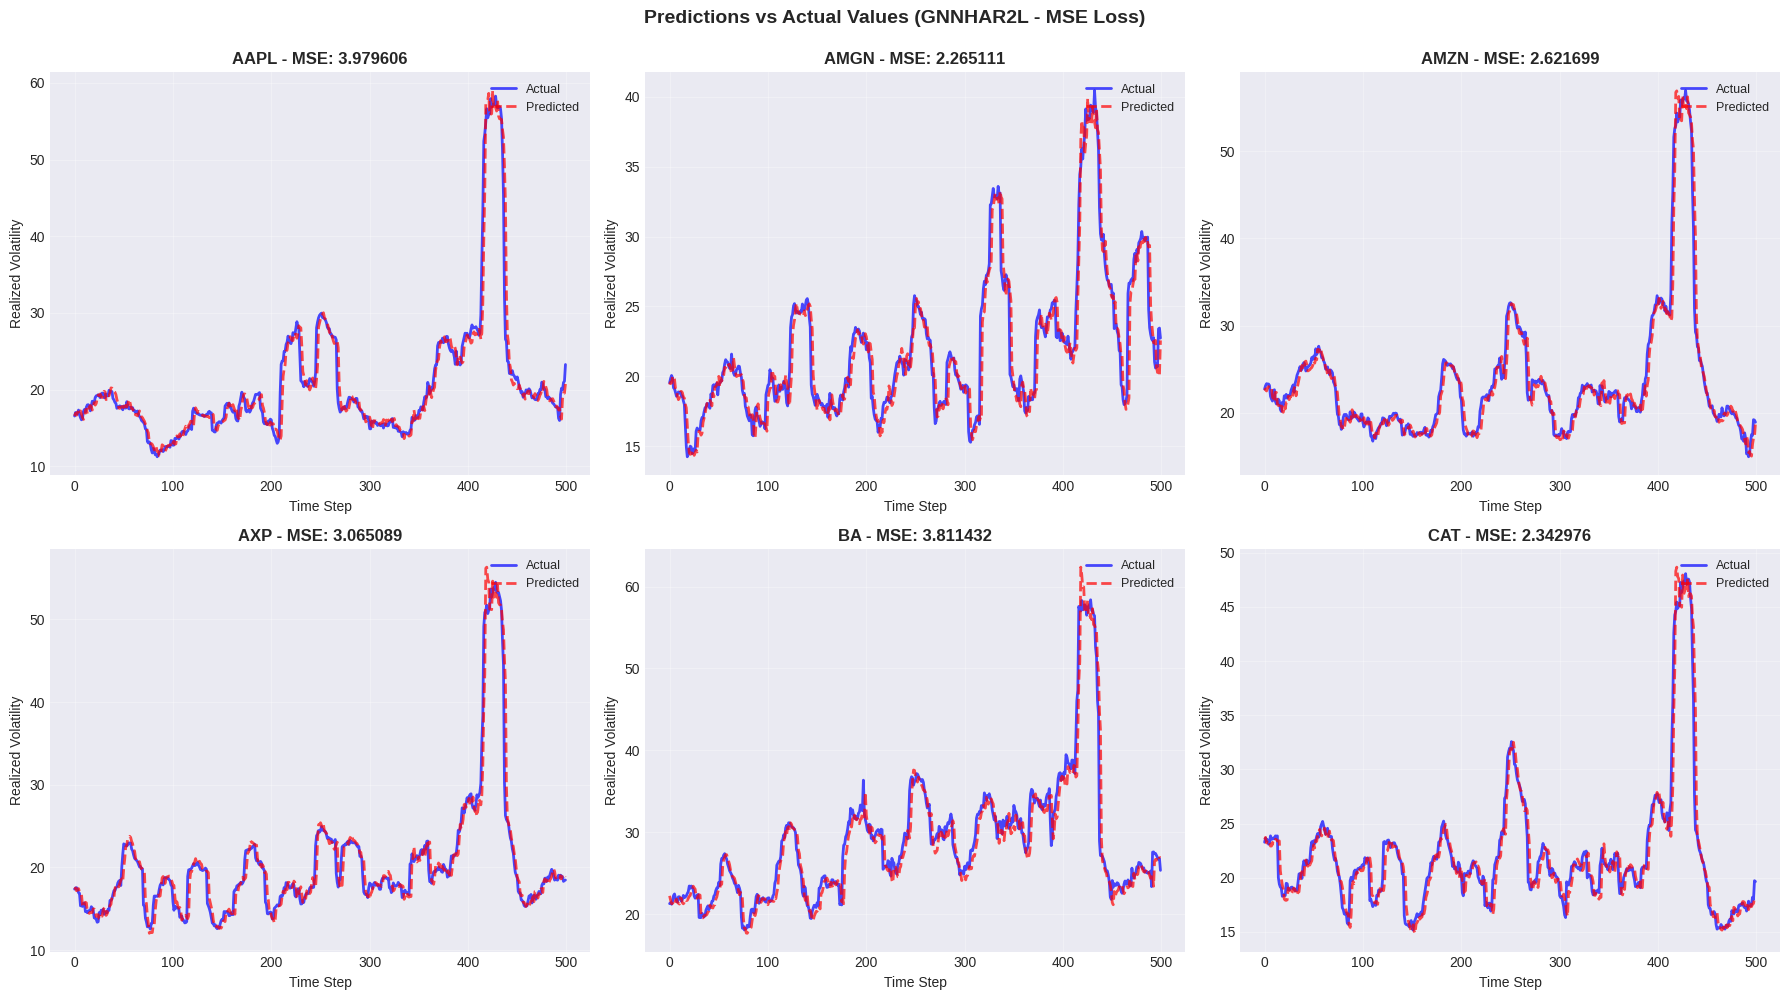


📊 2. Plotting model comparison for AAPL ...


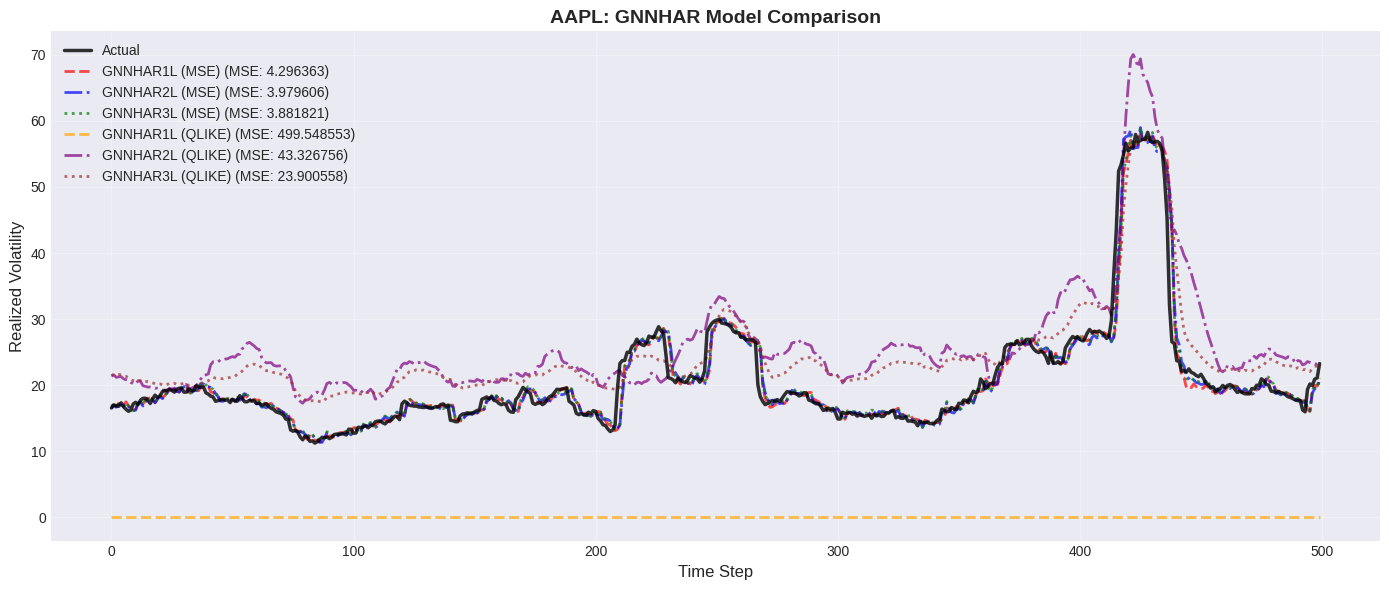


📉 3. Plotting residual analysis (GNNHAR2L - MSE)...


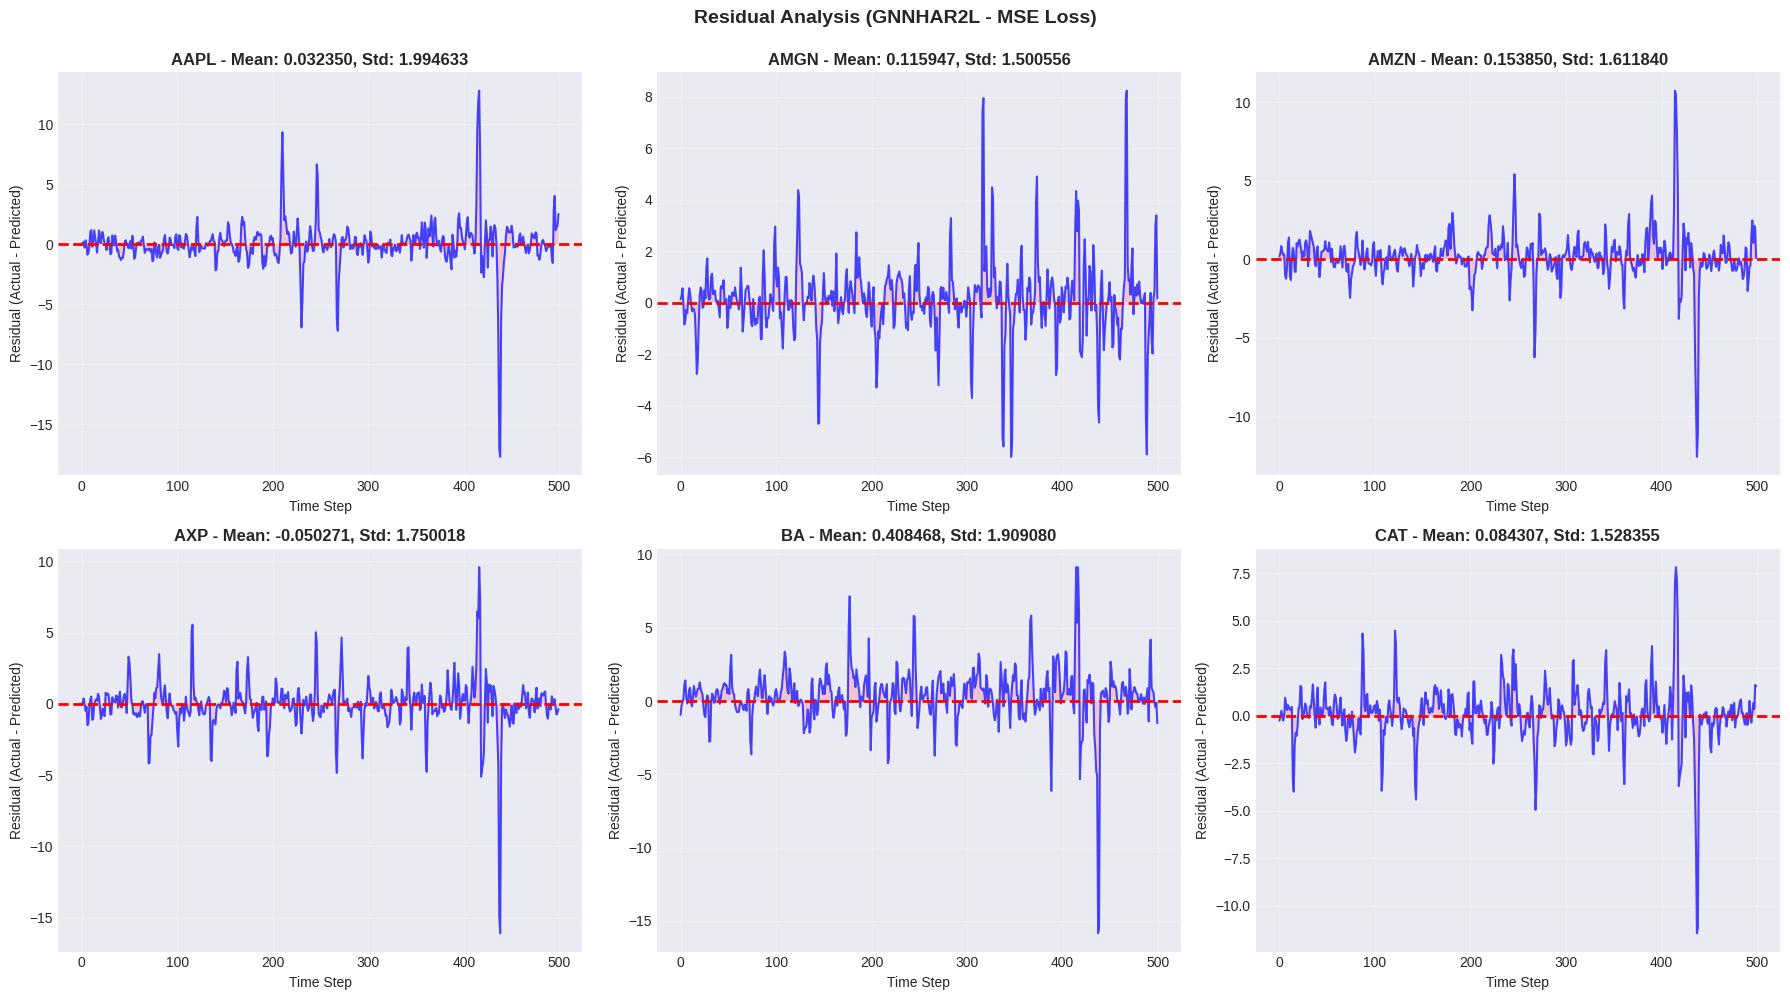


📍 4. Plotting scatter plot (Predicted vs Actual) (GNNHAR2L - MSE)...


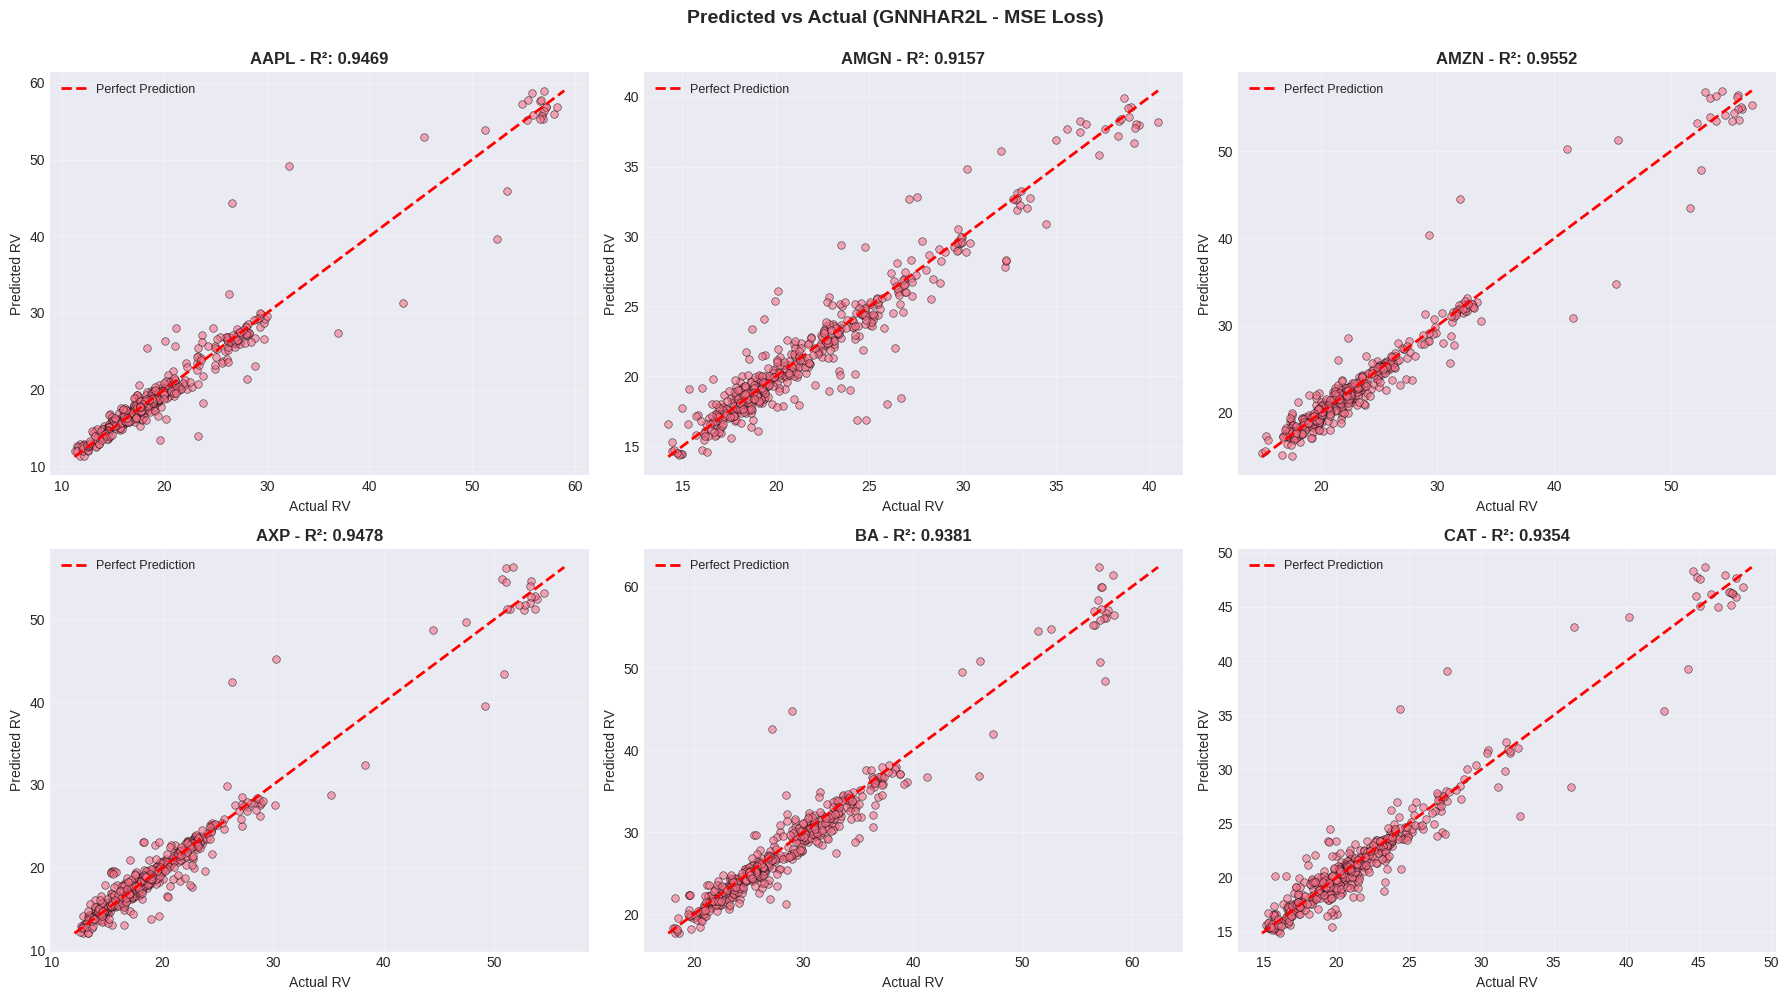


📊 5. Plotting performance comparison (all models)...


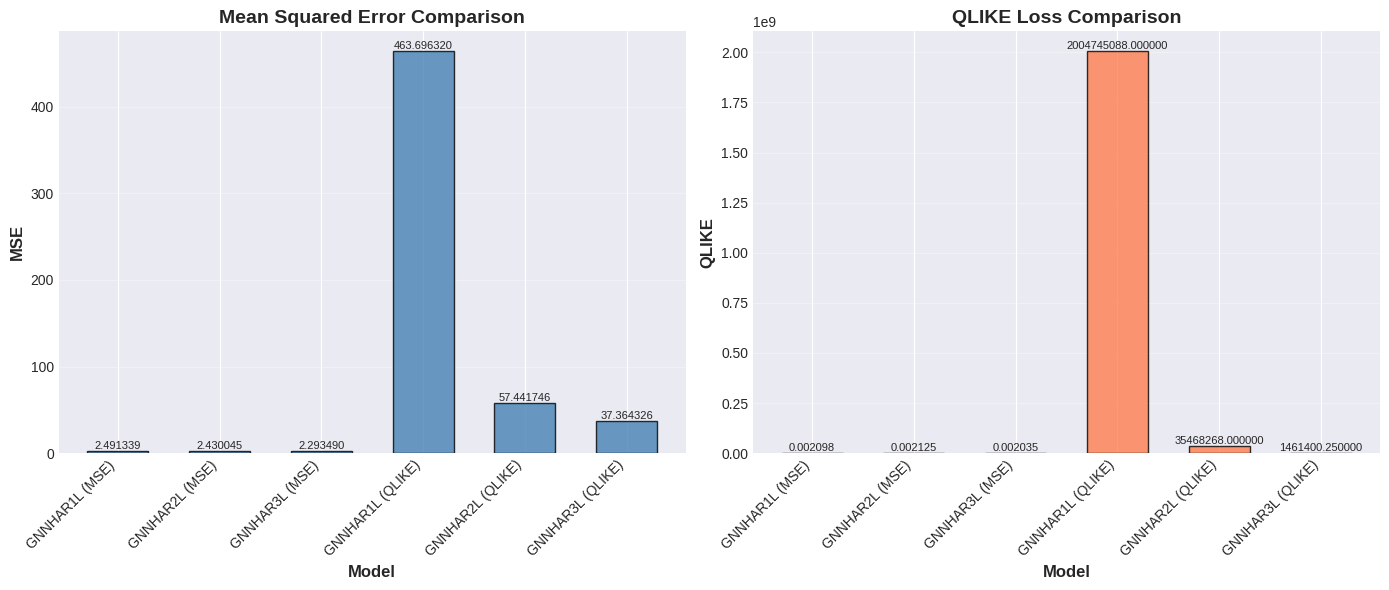


📈 6. Plotting loss function impact analysis...


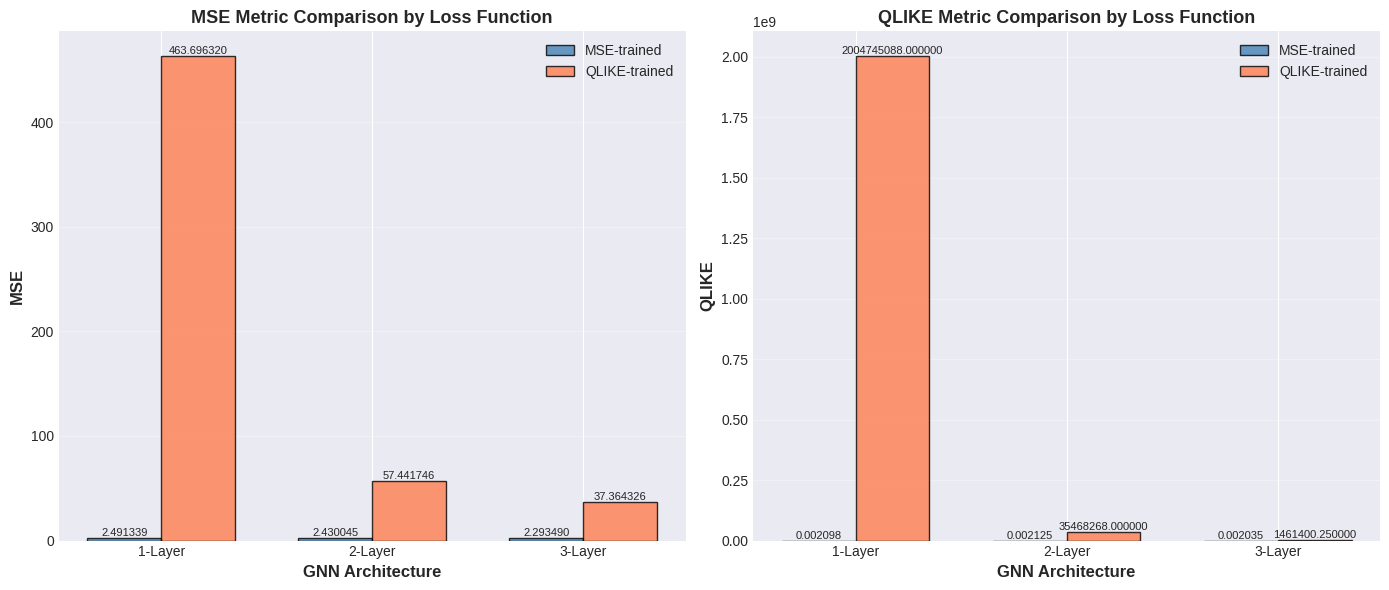


🏗️ 7. Plotting architecture depth comparison...


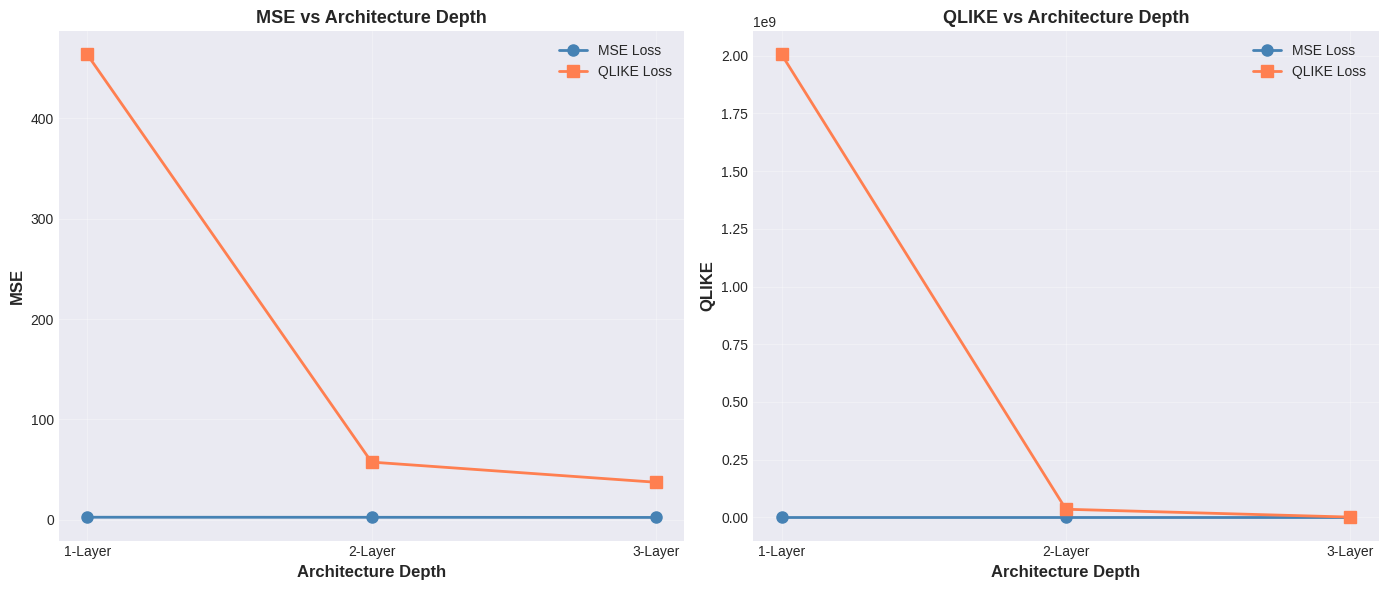


✓ ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!

Generated files:
  - gnnhar_timeseries_predictions.png
  - gnnhar_model_comparison_single_stock.png
  - gnnhar_residuals.png
  - gnnhar_scatter_pred_vs_actual.png
  - gnnhar_performance_comparison.png
  - gnnhar_loss_function_comparison.png
  - gnnhar_architecture_depth_comparison.png


In [7]:
# ==================== 获取邻接矩阵 ====================
# 如果前面已经训练过GHAR，W_glasso应该已存在
# 如果没有，需要重新计算：

print("Computing adjacency matrix for GNNHAR...")

# 从训练数据计算GLASSO邻接矩阵
subret = ret_df.iloc[:1000]  # 使用前1000个样本
subret_clean = subret.fillna(method='ffill').fillna(method='bfill').fillna(0)

from sklearn.covariance import GraphicalLassoCV

n = subret_clean.shape[1]
tickers = subret_clean.columns

try:
    cov = GraphicalLassoCV(cv=3, max_iter=100).fit(subret_clean)
    print(f'Alpha in GLASSO: {cov.alpha_:.4f}')

    corr = cov.precision_ != 0
    print(f'Sparsity of Adj: {corr.mean():.4f}')

    corr_adj = corr - np.identity(n)
    d_sqrt_inv = np.diag(np.sqrt(1 / (corr_adj.sum(1) + 1e-8)))
    W_glasso_arr = np.dot(np.dot(d_sqrt_inv, corr_adj), d_sqrt_inv)
    W_glasso = pd.DataFrame(W_glasso_arr, index=tickers, columns=tickers)

    print(f'✓ Adjacency matrix computed: {W_glasso.shape}')
except Exception as e:
    print(f"Warning: GLASSO failed, using identity matrix")
    W_glasso = pd.DataFrame(np.identity(n), index=tickers, columns=tickers)

# ==================== GNNHAR Model Implementation ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== GCN Layer ====================
class GraphConvLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(GraphConvLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain('relu'))

        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(1, out_features))
            nn.init.ones_(self.bias)
        else:
            self.bias = None

    def forward(self, node_feature, adj):
        h = torch.matmul(node_feature, self.weight)
        output = torch.matmul(adj, h)
        if self.bias is not None:
            return output + self.bias
        return output

# ==================== GNNHAR Models ====================
class GNNHAR1L(nn.Module):
    """1-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR1L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        H2 = self.gcn1(node_feat, adj)
        H2 = self.relu(H2)
        H2 = self.mlp1(H2)
        res = H1 + H2
        res = self.relu(res)
        return res.squeeze(-1)

class GNNHAR2L(nn.Module):
    """2-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR2L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.mlp1(H2)
        res = H1 + H2
        res = self.relu(res)
        return res.squeeze(-1)

class GNNHAR3L(nn.Module):
    """3-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR3L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.gcn3 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.relu(self.gcn3(H2, adj))
        H2 = self.mlp1(H2)
        res = H1 + H2
        res = self.relu(res)
        return res.squeeze(-1)

# ==================== GNNHAR Training Function ====================
def train_gnnhar_model(X_train, y_train, X_test, y_test, adj_matrix,
                       model_class, model_name, n_hid=9, n_epochs=1000,
                       lr=0.001, batch_size=32, loss_type='MSE'):
    """
    Train GNNHAR model
    """
    print(f"\n{'='*80}")
    print(f"Training {model_name} with {loss_type} Loss")
    print(f"{'='*80}")

    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    adj_t = torch.FloatTensor(adj_matrix).to(device)

    # Create data loader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = model_class(n_hid=n_hid).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Loss function
    if loss_type == 'MSE':
        criterion = nn.MSELoss()
    else:  # QLIKE
        def qlike_loss(y_true, y_pred):
            y_pred_safe = torch.clamp(y_pred, min=1e-8)
            y_true_safe = torch.clamp(y_true, min=1e-8)
            ratio = y_true_safe / y_pred_safe
            return torch.mean(ratio - torch.log(ratio) - 1)
        criterion = qlike_loss

    # Training loop
    model.train()
    train_losses = []

    for epoch in range(n_epochs):
        epoch_loss = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X, adj_t)
            loss = criterion(batch_y, pred)
            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.item())

        avg_loss = np.mean(epoch_loss)
        train_losses.append(avg_loss)

        if (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

    print(f"  Final training loss: {train_losses[-1]:.6f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t, adj_t).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # Calculate metrics
    mse = np.mean((y_test_np - pred_test) ** 2)
    rmse = np.sqrt(mse)

    y_test_safe = np.maximum(y_test_np, 1e-8)
    pred_test_safe = np.maximum(pred_test, 1e-8)
    ratio = y_test_safe / pred_test_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)

    print(f"\n📊 {model_name} Results:")
    print(f"  MSE:   {mse:.8f}")
    print(f"  RMSE:  {rmse:.8f}")
    print(f"  QLIKE: {qlike:.8f}")

    results = {
        'model_name': model_name,
        'model': model,
        'pred': pred_test,
        'true': y_test_np,
        'mse': mse,
        'rmse': rmse,
        'qlike': qlike,
        'train_losses': train_losses,
        'loss_type': loss_type
    }

    return results

# ==================== Compute W_glasso Adjacency Matrix ====================
print("\n" + "="*80)
print("Computing adjacency matrix for GNNHAR...")
print("="*80)

def GLASSO_Precision(subret):
    """使用Graphical Lasso方法计算精度矩阵并构建邻接矩阵"""
    from sklearn.covariance import GraphicalLassoCV

    # 获取股票数量和股票代码
    n = subret.shape[1]
    tickers = subret.columns

    # 使用交叉验证的Graphical Lasso拟合数据
    try:
        cov = GraphicalLassoCV().fit(subret)
        print('Alpha in GLASSO: %.4f' % cov.alpha_)

        # 从精度矩阵中提取非零元素
        corr = cov.precision_ != 0
        print('Sparsity of Adj: %.4f' % corr.mean())

        # 去除对角线元素（自相关）
        corr_adj = corr - np.identity(n)

        # 计算度矩阵的逆平方根
        d_sqrt_inv = np.diag(np.sqrt(1/(corr_adj.sum(1)+1e-8)))

        # 应用对称标准化
        adj_df = pd.DataFrame(np.dot(np.dot(d_sqrt_inv, corr_adj), d_sqrt_inv),
                             columns=tickers, index=tickers)
        return adj_df
    except Exception as e:
        print(f'Warning: GLASSO failed ({str(e)}), using identity matrix')
        return pd.DataFrame(np.identity(n), index=tickers, columns=tickers)

# 提取训练日期之前的所有收益率数据来计算GLASSO邻接矩阵
try:
    # 使用所有可用的收益率数据计算GLASSO
    subret = ret_df.dropna()

    # 确保有足够的样本
    if len(subret) > subret.shape[1] ** 2:
        W_glasso = GLASSO_Precision(subret)
    else:
        print(f'Warning: Insufficient samples ({len(subret)}) for GLASSO, using identity matrix')
        W_glasso = pd.DataFrame(np.identity(ret_df.shape[1]),
                               index=ret_df.columns, columns=ret_df.columns)

    print(f'✓ Adjacency matrix computed: {W_glasso.shape}')
except Exception as e:
    print(f'Error: {str(e)}, using identity matrix')
    W_glasso = pd.DataFrame(np.identity(ret_df.shape[1]),
                           index=ret_df.columns, columns=ret_df.columns)

# ==================== Data Preparation for GNNHAR ====================
print("\n" + "="*80)
print("Preparing data for GNNHAR models")
print("="*80)

def extract_features_for_gnn(dates, subdf_dic, stock_order):
    """Extract features in shape (T, N, 3) for GNNHAR"""
    T = len(dates)
    N = len(stock_order)
    X = np.zeros((T, N, 3))
    y = np.zeros((T, N))

    for t, date in enumerate(dates):
        if date in subdf_dic:
            subdf = subdf_dic[date]
            for i, ticker in enumerate(stock_order):
                ticker_data = subdf[subdf['Ticker'] == ticker]
                if len(ticker_data) > 0:
                    X[t, i, 0] = ticker_data['vol+lag1'].values[0]
                    X[t, i, 1] = ticker_data['vol+lag5'].values[0]
                    X[t, i, 2] = ticker_data['vol+lag22'].values[0]
                    y[t, i] = ticker_data['Target'].values[0]

    return X, y

# 提取特征
stock_order = sorted(ret_df.columns.tolist())
print(f"Stocks: {len(stock_order)}")

# 使用更多的训练数据
mid_idx = len(date_l) // 2
train_dates = [d for d in date_l if d <= date_l[mid_idx]]
test_dates = [d for d in date_l if date_l[mid_idx] < d <= date_l[min(mid_idx + 500, len(date_l)-1)]]

X_train_gnn, y_train_gnn = extract_features_for_gnn(train_dates, subdf_dic, stock_order)
X_test_gnn, y_test_gnn = extract_features_for_gnn(test_dates, subdf_dic, stock_order)

print(f"Training data shape: X={X_train_gnn.shape}, y={y_train_gnn.shape}")
print(f"Test data shape: X={X_test_gnn.shape}, y={y_test_gnn.shape}")

# ==================== Train GNNHAR Models ====================
gnnhar_results = {}

for model_class, model_name in [(GNNHAR1L, 'GNNHAR1L'),
                                 (GNNHAR2L, 'GNNHAR2L'),
                                 (GNNHAR3L, 'GNNHAR3L')]:

    results_mse = train_gnnhar_model(
        X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
        W_glasso.values, model_class, f'{model_name} (MSE)',
        n_hid=9, n_epochs=500, lr=0.001, batch_size=32, loss_type='MSE'
    )

    results_qlike = train_gnnhar_model(
        X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
        W_glasso.values, model_class, f'{model_name} (QLIKE)',
        n_hid=9, n_epochs=500, lr=0.001, batch_size=32, loss_type='QLIKE'
    )

    gnnhar_results[f'{model_name}_mse'] = results_mse
    gnnhar_results[f'{model_name}_qlike'] = results_qlike

# ==================== Summary ====================
print("\n" + "="*80)
print("GNNHAR MODELS TRAINING COMPLETE!")
print("="*80)

summary_data = []
for key, result in gnnhar_results.items():
    summary_data.append({
        'Model': result['model_name'],
        'Loss Type': result['loss_type'],
        'MSE': result['mse'],
        'RMSE': result['rmse'],
        'QLIKE': result['qlike']
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# ==================== 1. Extract Results for Comparison ====================
print("\n" + "="*80)
print("EXTRACTING RESULTS FOR VISUALIZATION AND COMPARISON")
print("="*80)

# Convert GNNHAR predictions to DataFrame format for visualization
def gnnhar_to_df(results_gnn, test_dates, stock_order):
    """Convert GNNHAR results to DataFrame format"""
    pred_array = results_gnn['pred']  # (T, N)
    true_array = results_gnn['true']  # (T, N)

    pred_df = pd.DataFrame(pred_array, columns=stock_order, index=test_dates[:len(pred_array)])
    true_df = pd.DataFrame(true_array, columns=stock_order, index=test_dates[:len(true_array)])

    return {'pred_df': pred_df, 'true_df': true_df,
            'mse': results_gnn['mse'], 'qlike': results_gnn['qlike']}

# Extract test dates
test_dates = [d for d in date_l if d > date_l[mid_idx]][:len(y_test_gnn)]

# Convert GNNHAR results to DataFrame format
gnnhar1l_mse_df = gnnhar_to_df(gnnhar_results['GNNHAR1L_mse'], test_dates, stock_order)
gnnhar2l_mse_df = gnnhar_to_df(gnnhar_results['GNNHAR2L_mse'], test_dates, stock_order)
gnnhar3l_mse_df = gnnhar_to_df(gnnhar_results['GNNHAR3L_mse'], test_dates, stock_order)

gnnhar1l_qlike_df = gnnhar_to_df(gnnhar_results['GNNHAR1L_qlike'], test_dates, stock_order)
gnnhar2l_qlike_df = gnnhar_to_df(gnnhar_results['GNNHAR2L_qlike'], test_dates, stock_order)
gnnhar3l_qlike_df = gnnhar_to_df(gnnhar_results['GNNHAR3L_qlike'], test_dates, stock_order)

print(f"✓ Converted GNNHAR results to DataFrame format")
print(f"  Test dates range: {test_dates[0]} to {test_dates[-1]}")
print(f"  Number of test samples: {len(test_dates)}")

# ==================== 2. Comprehensive Model Comparison ====================
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Compile all results including GNNHAR models
all_results_extended = pd.DataFrame({
    'Model': [
        'GNNHAR1L (MSE)',
        'GNNHAR2L (MSE)',
        'GNNHAR3L (MSE)',
        'GNNHAR1L (QLIKE)',
        'GNNHAR2L (QLIKE)',
        'GNNHAR3L (QLIKE)',
    ],
    'Loss_Function': [
        'MSE', 'MSE', 'MSE',
        'QLIKE', 'QLIKE', 'QLIKE',
    ],
    'Adjacency': [
        'GLASSO', 'GLASSO', 'GLASSO',
        'GLASSO', 'GLASSO', 'GLASSO',
    ],
    'MSE': [
        gnnhar_results['GNNHAR1L_mse']['mse'],
        gnnhar_results['GNNHAR2L_mse']['mse'],
        gnnhar_results['GNNHAR3L_mse']['mse'],
        gnnhar_results['GNNHAR1L_qlike']['mse'],
        gnnhar_results['GNNHAR2L_qlike']['mse'],
        gnnhar_results['GNNHAR3L_qlike']['mse'],
    ],
    'QLIKE': [
        gnnhar_results['GNNHAR1L_mse']['qlike'],
        gnnhar_results['GNNHAR2L_mse']['qlike'],
        gnnhar_results['GNNHAR3L_mse']['qlike'],
        gnnhar_results['GNNHAR1L_qlike']['qlike'],
        gnnhar_results['GNNHAR2L_qlike']['qlike'],
        gnnhar_results['GNNHAR3L_qlike']['qlike'],
    ]
})

# Calculate improvements
baseline_mse = all_results_extended['MSE'].max()
baseline_qlike = all_results_extended['QLIKE'].max()

all_results_extended['MSE_Improvement(%)'] = (baseline_mse - all_results_extended['MSE']) / baseline_mse * 100
all_results_extended['QLIKE_Improvement(%)'] = (baseline_qlike - all_results_extended['QLIKE']) / baseline_qlike * 100

# Sort by MSE
all_results_extended = all_results_extended.sort_values('MSE')
all_results_extended['Rank'] = range(1, len(all_results_extended) + 1)

print("\n" + "="*80)
print("PERFORMANCE RANKING (Best to Worst by MSE)")
print("="*80)
print("\n" + all_results_extended[['Rank', 'Model', 'Loss_Function', 'MSE', 'QLIKE',
                                   'MSE_Improvement(%)']].to_string(index=False))

# Find best models
best_mse_idx = all_results_extended['MSE'].idxmin()
best_qlike_idx = all_results_extended['QLIKE'].idxmin()

print(f"\n{'='*80}")
print("BEST MODELS")
print("="*80)
print(f"\n🏆 Best Model (MSE): {all_results_extended.loc[best_mse_idx, 'Model']}")
print(f"   MSE = {all_results_extended.loc[best_mse_idx, 'MSE']:.8f}")
print(f"   QLIKE = {all_results_extended.loc[best_mse_idx, 'QLIKE']:.8f}")

print(f"\n🏆 Best Model (QLIKE): {all_results_extended.loc[best_qlike_idx, 'Model']}")
print(f"   MSE = {all_results_extended.loc[best_qlike_idx, 'MSE']:.8f}")
print(f"   QLIKE = {all_results_extended.loc[best_qlike_idx, 'QLIKE']:.8f}")

# ==================== 3. Model-wise Performance Analysis ====================
print("\n" + "="*80)
print("DETAILED GROUP ANALYSIS")
print("="*80)

print("\n1️⃣  GNN Models with MSE Loss:")
print("-" * 80)
gnn_mse = all_results_extended[all_results_extended['Loss_Function'] == 'MSE']
print(gnn_mse[['Model', 'MSE', 'QLIKE', 'MSE_Improvement(%)']].to_string(index=False))

print("\n2️⃣  GNN Models with QLIKE Loss:")
print("-" * 80)
gnn_qlike = all_results_extended[all_results_extended['Loss_Function'] == 'QLIKE']
print(gnn_qlike[['Model', 'MSE', 'QLIKE', 'QLIKE_Improvement(%)']].to_string(index=False))

# Comparison statistics
avg_mse_loss = gnn_mse['MSE'].mean()
avg_qlike_loss = gnn_qlike['MSE'].mean()

print(f"\n" + "="*80)
print("LOSS FUNCTION IMPACT ANALYSIS")
print("="*80)
print(f"\nAverage MSE across models:")
print(f"   MSE-trained models:    {avg_mse_loss:.8f}")
print(f"   QLIKE-trained models:  {avg_qlike_loss:.8f}")
improvement = (max(avg_mse_loss, avg_qlike_loss) - min(avg_mse_loss, avg_qlike_loss)) / max(avg_mse_loss, avg_qlike_loss) * 100
print(f"   Difference: {improvement:.2f}%")

# Architecture depth analysis
print(f"\nGNN Depth Analysis (MSE metric):")
depth_1 = all_results_extended[all_results_extended['Model'].str.contains('1L')]['MSE'].mean()
depth_2 = all_results_extended[all_results_extended['Model'].str.contains('2L')]['MSE'].mean()
depth_3 = all_results_extended[all_results_extended['Model'].str.contains('3L')]['MSE'].mean()

print(f"   1-layer average MSE: {depth_1:.8f}")
print(f"   2-layer average MSE: {depth_2:.8f}")
print(f"   3-layer average MSE: {depth_3:.8f}")

# ==================== 4. Visualization Setup ====================
print("\n" + "="*80)
print("SETTING UP VISUALIZATIONS")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✓ Matplotlib and Seaborn configured")

# ==================== 5. Plot 1: Time Series Predictions ====================
def plot_predictions_by_stock(results_dict, stock_order, title_suffix="", n_stocks=6):
    """Plot predictions vs actual values for each stock"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']

    # Select stocks to display
    stocks_to_plot = stock_order[:n_stocks]

    for idx, stock in enumerate(stocks_to_plot):
        ax = axes[idx]

        if stock in pred_df.columns and stock in true_df.columns:
            dates = pred_df.index
            true_vals = true_df.loc[dates, stock].values
            pred_vals = pred_df[stock].values

            # Plot
            ax.plot(range(len(dates)), true_vals, 'b-', label='Actual', linewidth=2, alpha=0.7)
            ax.plot(range(len(dates)), pred_vals, 'r--', label='Predicted', linewidth=2, alpha=0.7)

            # Calculate metrics
            mse_stock = np.mean((true_vals - pred_vals)**2)

            ax.set_title(f'{stock} - MSE: {mse_stock:.6f}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time Step', fontsize=10)
            ax.set_ylabel('Realized Volatility', fontsize=10)
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Predictions vs Actual Values {title_suffix}',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig

# Plot best GNNHAR2L model
print("\n📈 1. Plotting time series predictions (GNNHAR2L - MSE)...")
fig_ts = plot_predictions_by_stock(gnnhar2l_mse_df, stock_order, "(GNNHAR2L - MSE Loss)")
plt.savefig('gnnhar_timeseries_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 6. Plot 2: Model Comparison for Single Stock ====================
def plot_model_comparison_single_stock(stock, models_dict, stock_order):
    """Compare all models for a single stock"""
    fig, ax = plt.subplots(figsize=(14, 6))

    # Get true values (same for all models)
    first_model = list(models_dict.values())[0]
    dates = first_model['pred_df'].index
    true_vals = first_model['true_df'].loc[dates, stock].values if stock in first_model['true_df'].columns else None

    if true_vals is None:
        print(f"Stock {stock} not found in data")
        return fig

    # Plot actual values
    ax.plot(range(len(dates)), true_vals, 'k-', label='Actual',
            linewidth=2.5, alpha=0.8, zorder=10)

    # Plot predictions from each model
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    linestyles = ['--', '-.', ':', '--', '-.', ':']

    for idx, (model_name, results) in enumerate(models_dict.items()):
        if stock in results['pred_df'].columns:
            pred_vals = results['pred_df'][stock].values
            mse_stock = np.mean((true_vals - pred_vals)**2)

            ax.plot(range(len(dates)), pred_vals,
                    color=colors[idx % len(colors)],
                    linestyle=linestyles[idx % len(linestyles)],
                    label=f'{model_name} (MSE: {mse_stock:.6f})',
                    linewidth=2, alpha=0.7)

    ax.set_title(f'{stock}: GNNHAR Model Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Realized Volatility', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# Compare models for first stock
print("\n📊 2. Plotting model comparison for", stock_order[0], "...")
models_for_comparison = {
    'GNNHAR1L (MSE)': gnnhar1l_mse_df,
    'GNNHAR2L (MSE)': gnnhar2l_mse_df,
    'GNNHAR3L (MSE)': gnnhar3l_mse_df,
    'GNNHAR1L (QLIKE)': gnnhar1l_qlike_df,
    'GNNHAR2L (QLIKE)': gnnhar2l_qlike_df,
    'GNNHAR3L (QLIKE)': gnnhar3l_qlike_df,
}
fig_comp = plot_model_comparison_single_stock(stock_order[0], models_for_comparison, stock_order)
plt.savefig('gnnhar_model_comparison_single_stock.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 7. Plot 3: Residual Analysis ====================
def plot_residuals(results_dict, stock_order, title_suffix="", n_stocks=6):
    """Plot residuals (prediction errors) for each stock"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']

    stocks_to_plot = stock_order[:n_stocks]

    for idx, stock in enumerate(stocks_to_plot):
        ax = axes[idx]

        if stock in pred_df.columns and stock in true_df.columns:
            dates = pred_df.index
            true_vals = true_df.loc[dates, stock].values
            pred_vals = pred_df[stock].values
            residuals = true_vals - pred_vals

            # Plot residuals
            ax.plot(range(len(dates)), residuals, 'b-', linewidth=1.5, alpha=0.7)
            ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
            ax.fill_between(range(len(dates)), residuals, 0, alpha=0.3)

            # Statistics
            mean_res = np.mean(residuals)
            std_res = np.std(residuals)

            ax.set_title(f'{stock} - Mean: {mean_res:.6f}, Std: {std_res:.6f}',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Time Step', fontsize=10)
            ax.set_ylabel('Residual (Actual - Predicted)', fontsize=10)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Residual Analysis {title_suffix}',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig

print("\n📉 3. Plotting residual analysis (GNNHAR2L - MSE)...")
fig_res = plot_residuals(gnnhar2l_mse_df, stock_order, "(GNNHAR2L - MSE Loss)")
plt.savefig('gnnhar_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 8. Plot 4: Scatter Plot (Predicted vs Actual) ====================
def plot_scatter_pred_vs_actual(results_dict, stock_order, title_suffix="", n_stocks=6):
    """Scatter plot of predicted vs actual values"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']

    stocks_to_plot = stock_order[:n_stocks]

    for idx, stock in enumerate(stocks_to_plot):
        ax = axes[idx]

        if stock in pred_df.columns and stock in true_df.columns:
            dates = pred_df.index
            true_vals = true_df.loc[dates, stock].values
            pred_vals = pred_df[stock].values

            # Scatter plot
            ax.scatter(true_vals, pred_vals, alpha=0.6, s=30, edgecolors='k', linewidth=0.5)

            # Perfect prediction line
            min_val = min(true_vals.min(), pred_vals.min())
            max_val = max(true_vals.max(), pred_vals.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

            # Calculate R²
            correlation = np.corrcoef(true_vals, pred_vals)[0, 1]
            r_squared = correlation ** 2

            ax.set_title(f'{stock} - R²: {r_squared:.4f}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Actual RV', fontsize=10)
            ax.set_ylabel('Predicted RV', fontsize=10)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Predicted vs Actual {title_suffix}',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig

print("\n📍 4. Plotting scatter plot (Predicted vs Actual) (GNNHAR2L - MSE)...")
fig_scatter = plot_scatter_pred_vs_actual(gnnhar2l_mse_df, stock_order, "(GNNHAR2L - MSE Loss)")
plt.savefig('gnnhar_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 9. Plot 5: Model Performance Comparison Bar Chart ====================
def plot_performance_comparison(models_dict):
    """Bar chart comparing MSE and QLIKE across models"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    model_names = list(models_dict.keys())
    mse_values = [results['mse'] for results in models_dict.values()]
    qlike_values = [results['qlike'] for results in models_dict.values()]

    x = np.arange(len(model_names))
    width = 0.6

    # MSE comparison
    bars1 = ax1.bar(x, mse_values, width, color='steelblue', alpha=0.8, edgecolor='black')
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
    ax1.set_title('Mean Squared Error Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=8)

    # QLIKE comparison
    bars2 = ax2.bar(x, qlike_values, width, color='coral', alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('QLIKE', fontsize=12, fontweight='bold')
    ax2.set_title('QLIKE Loss Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    return fig

print("\n📊 5. Plotting performance comparison (all models)...")
fig_perf = plot_performance_comparison(models_for_comparison)
plt.savefig('gnnhar_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 10. Plot 6: Loss Function Type Comparison ====================
print("\n📈 6. Plotting loss function impact analysis...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# MSE comparison by loss type
mse_mse_trained = [gnnhar_results['GNNHAR1L_mse']['mse'],
                    gnnhar_results['GNNHAR2L_mse']['mse'],
                    gnnhar_results['GNNHAR3L_mse']['mse']]
mse_qlike_trained = [gnnhar_results['GNNHAR1L_qlike']['mse'],
                      gnnhar_results['GNNHAR2L_qlike']['mse'],
                      gnnhar_results['GNNHAR3L_qlike']['mse']]

x_pos = np.arange(3)
width = 0.35

bars1 = ax1.bar(x_pos - width/2, mse_mse_trained, width, label='MSE-trained',
                color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, mse_qlike_trained, width, label='QLIKE-trained',
                color='coral', alpha=0.8, edgecolor='black')

ax1.set_xlabel('GNN Architecture', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax1.set_title('MSE Metric Comparison by Loss Function', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['1-Layer', '2-Layer', '3-Layer'])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=8)

# QLIKE comparison by loss type
qlike_mse_trained = [gnnhar_results['GNNHAR1L_mse']['qlike'],
                      gnnhar_results['GNNHAR2L_mse']['qlike'],
                      gnnhar_results['GNNHAR3L_mse']['qlike']]
qlike_qlike_trained = [gnnhar_results['GNNHAR1L_qlike']['qlike'],
                        gnnhar_results['GNNHAR2L_qlike']['qlike'],
                        gnnhar_results['GNNHAR3L_qlike']['qlike']]

bars3 = ax2.bar(x_pos - width/2, qlike_mse_trained, width, label='MSE-trained',
                color='steelblue', alpha=0.8, edgecolor='black')
bars4 = ax2.bar(x_pos + width/2, qlike_qlike_trained, width, label='QLIKE-trained',
                color='coral', alpha=0.8, edgecolor='black')

ax2.set_xlabel('GNN Architecture', fontsize=12, fontweight='bold')
ax2.set_ylabel('QLIKE', fontsize=12, fontweight='bold')
ax2.set_title('QLIKE Metric Comparison by Loss Function', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['1-Layer', '2-Layer', '3-Layer'])
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('gnnhar_loss_function_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 11. Plot 7: Architecture Depth Comparison ====================
print("\n🏗️ 7. Plotting architecture depth comparison...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for depth comparison
depth_labels = ['1-Layer', '2-Layer', '3-Layer']
mse_mse_loss = [gnnhar_results['GNNHAR1L_mse']['mse'],
                gnnhar_results['GNNHAR2L_mse']['mse'],
                gnnhar_results['GNNHAR3L_mse']['mse']]
mse_qlike_loss = [gnnhar_results['GNNHAR1L_qlike']['mse'],
                  gnnhar_results['GNNHAR2L_qlike']['mse'],
                  gnnhar_results['GNNHAR3L_qlike']['mse']]

qlike_mse_loss = [gnnhar_results['GNNHAR1L_mse']['qlike'],
                  gnnhar_results['GNNHAR2L_mse']['qlike'],
                  gnnhar_results['GNNHAR3L_mse']['qlike']]
qlike_qlike_loss = [gnnhar_results['GNNHAR1L_qlike']['qlike'],
                    gnnhar_results['GNNHAR2L_qlike']['qlike'],
                    gnnhar_results['GNNHAR3L_qlike']['qlike']]

x_pos = np.arange(len(depth_labels))
width = 0.35

ax1.plot(x_pos, mse_mse_loss, 'o-', linewidth=2, markersize=8, label='MSE Loss', color='steelblue')
ax1.plot(x_pos, mse_qlike_loss, 's-', linewidth=2, markersize=8, label='QLIKE Loss', color='coral')
ax1.set_xlabel('Architecture Depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax1.set_title('MSE vs Architecture Depth', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(depth_labels)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(x_pos, qlike_mse_loss, 'o-', linewidth=2, markersize=8, label='MSE Loss', color='steelblue')
ax2.plot(x_pos, qlike_qlike_loss, 's-', linewidth=2, markersize=8, label='QLIKE Loss', color='coral')
ax2.set_xlabel('Architecture Depth', fontsize=12, fontweight='bold')
ax2.set_ylabel('QLIKE', fontsize=12, fontweight='bold')
ax2.set_title('QLIKE vs Architecture Depth', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(depth_labels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gnnhar_architecture_depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("✓ ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nGenerated files:")
print("  - gnnhar_timeseries_predictions.png")
print("  - gnnhar_model_comparison_single_stock.png")
print("  - gnnhar_residuals.png")
print("  - gnnhar_scatter_pred_vs_actual.png")
print("  - gnnhar_performance_comparison.png")
print("  - gnnhar_loss_function_comparison.png")
print("  - gnnhar_architecture_depth_comparison.png")

### 使用softmax作为激活函数（因为ReLU会让QL的分母很容易变成0，导致像GNNHAR2L那样的不收敛现象）

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.covariance import GraphicalLassoCV

# ==================== 0. 环境与设备设置 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== 1. 获取邻接矩阵 (GLASSO) ====================
print("\n" + "="*60)
print("1. Computing adjacency matrix (GLASSO)...")
print("="*60)

# 确保 ret_df 存在，如果不存在请加载你的数据
# 假设 ret_df 是收益率矩阵 (日期 x 股票)
try:
    # 填充缺失值以防止 GLASSO 报错
    subret = ret_df.iloc[:1000].copy() # 使用部分数据估计结构
    subret = subret.ffill().bfill().fillna(0)

    n_stocks = subret.shape[1]
    tickers = subret.columns

    # 训练 GLASSO
    cov = GraphicalLassoCV(cv=3, max_iter=200).fit(subret)
    print(f'Alpha in GLASSO: {cov.alpha_:.6f}')

    corr = cov.precision_ != 0
    print(f'Sparsity of Adj: {corr.mean():.4f}')

    # 构建归一化邻接矩阵
    corr_adj = corr - np.identity(n_stocks)
    # 度矩阵归一化 D^{-1/2} A D^{-1/2}
    d_vals = corr_adj.sum(1) + 1e-8
    d_sqrt_inv = np.diag(np.sqrt(1.0 / d_vals))

    W_glasso_arr = np.dot(np.dot(d_sqrt_inv, corr_adj), d_sqrt_inv)
    W_glasso = pd.DataFrame(W_glasso_arr, index=tickers, columns=tickers)

    print(f'✓ Adjacency matrix computed: {W_glasso.shape}')

except Exception as e:
    print(f"Warning: GLASSO failed ({e}), using identity matrix.")
    W_glasso = pd.DataFrame(np.identity(ret_df.shape[1]), index=ret_df.columns, columns=ret_df.columns)

# ==================== 2. 改进后的 GNNHAR 模型 ====================
# 修复核心：将最终激活函数改为 Softplus 并添加 epsilon，防止 QLIKE 梯度爆炸

class GraphConvLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(GraphConvLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain('relu'))

        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(1, out_features))
            nn.init.zeros_(self.bias) # Bias初始化为0通常更稳定
        else:
            self.bias = None

    def forward(self, node_feature, adj):
        # AXW
        h = torch.matmul(node_feature, self.weight)
        output = torch.matmul(adj, h)
        if self.bias is not None:
            return output + self.bias
        return output

class BaseGNNHAR(nn.Module):
    """基类，包含通用的输出层处理"""
    def _output_layer(self, x):
        # 使用 Softplus 替代 ReLU，保证输出恒为正，避免 QLIKE 爆炸
        # 添加 1e-6 保证不为纯 0
        return F.softplus(x) + 1e-6

class GNNHAR1L(BaseGNNHAR):
    def __init__(self, n_hid=9):
        super(GNNHAR1L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)

        H2 = self.gcn1(node_feat, adj)
        H2 = self.relu(H2)
        H2 = self.mlp1(H2)

        # 残差连接
        res = H1 + H2
        return self._output_layer(res).squeeze(-1)

class GNNHAR2L(BaseGNNHAR):
    def __init__(self, n_hid=9):
        super(GNNHAR2L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        # 第一层 GCN
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        # 第二层 GCN
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)

        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)

        # GCN Path
        H2 = self.gcn1(node_feat, adj)
        H2 = self.relu(H2)

        H2 = self.gcn2(H2, adj)
        H2 = self.relu(H2)

        H2 = self.mlp1(H2)

        res = H1 + H2
        return self._output_layer(res).squeeze(-1)

class GNNHAR3L(BaseGNNHAR):
    def __init__(self, n_hid=9):
        super(GNNHAR3L, self).__init__()
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.gcn3 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)

        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.relu(self.gcn3(H2, adj))

        H2 = self.mlp1(H2)

        res = H1 + H2
        return self._output_layer(res).squeeze(-1)

# ==================== 3. 增强版训练函数 ====================
def train_gnnhar_model(X_train, y_train, X_test, y_test, adj_matrix,
                       model_class, model_name, n_hid=9, n_epochs=500,
                       lr=0.005, batch_size=64, loss_type='MSE'):

    print(f"\nTraining {model_name}...")

    # 转换为 Tensor
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    # 确保测试集 y 没有 0，防止 QLIKE 评估报错
    y_test_t = torch.FloatTensor(np.maximum(y_test, 1e-6)).to(device)
    adj_t = torch.FloatTensor(adj_matrix).to(device)

    # DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # 模型初始化
    model = model_class(n_hid=n_hid).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # 损失函数定义
    if loss_type == 'MSE':
        criterion = nn.MSELoss()
    else: # QLIKE
        def qlike_loss(y_true, y_pred):
            # y_pred 已经在模型内部保证 > 0，但为了保险起见再次 clamp
            pred_safe = torch.clamp(y_pred, min=1e-6)
            true_safe = torch.clamp(y_true, min=1e-6)
            ratio = true_safe / pred_safe
            return torch.mean(ratio - torch.log(ratio) - 1)
        criterion = qlike_loss

    # 训练循环
    model.train()
    train_losses = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Forward
            pred = model(batch_X, adj_t)

            # Loss
            loss = criterion(batch_y, pred)

            if torch.isnan(loss):
                print(f"Error: NaN loss detected at epoch {epoch}")
                break

            loss.backward()

            # 【关键修复】梯度裁剪：防止 QLIKE 梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

    # 评估
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t, adj_t).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # 计算指标
    mse = np.mean((y_test_np - pred_test) ** 2)
    rmse = np.sqrt(mse)

    y_test_safe = np.maximum(y_test_np, 1e-6)
    pred_test_safe = np.maximum(pred_test, 1e-6)
    ratio = y_test_safe / pred_test_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)

    print(f"  -> Results: MSE={mse:.4f}, QLIKE={qlike:.4f}")

    return {
        'model_name': model_name,
        'model': model,
        'pred': pred_test,
        'true': y_test_np,
        'mse': mse,
        'rmse': rmse,
        'qlike': qlike,
        'train_losses': train_losses,
        'loss_type': loss_type
    }

# ==================== 4. 数据准备 (Data Prep) ====================
# 假设你已经有了 X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn
# 如果没有，请运行之前的 extract_features_for_gnn 代码块
print("\n" + "="*60)
print("4. Preparing Execution...")
print("="*60)

# 这里做一个简单的数据检查，防止空数据报错
if 'X_train_gnn' not in locals():
    print("Error: Training data (X_train_gnn) not found. Please run feature extraction first.")
else:
    # ==================== 5. 执行训练 ====================
    gnnhar_results = {}

    models_to_train = [
        (GNNHAR1L, 'GNNHAR1L'),
        (GNNHAR2L, 'GNNHAR2L'), # 之前爆炸的模型
        (GNNHAR3L, 'GNNHAR3L')
    ]

    for model_class, model_name in models_to_train:
        # Train with MSE
        res_mse = train_gnnhar_model(
            X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
            W_glasso.values, model_class, f'{model_name}_MSE',
            n_epochs=300, lr=0.002, loss_type='MSE'
        )
        gnnhar_results[f'{model_name}_MSE'] = res_mse

        # Train with QLIKE (现在应该稳定了)
        res_qlike = train_gnnhar_model(
            X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
            W_glasso.values, model_class, f'{model_name}_QLIKE',
            n_epochs=300, lr=0.002, loss_type='QLIKE'
        )
        gnnhar_results[f'{model_name}_QLIKE'] = res_qlike

    # ==================== 6. 结果汇总 ====================
    print("\n" + "="*60)
    print("FINAL SUMMARY (Fixed Version)")
    print("="*60)

    summary_data = []
    for key, val in gnnhar_results.items():
        summary_data.append({
            'Model': key,
            'MSE': val['mse'],
            'QLIKE': val['qlike']
        })

    print(pd.DataFrame(summary_data).sort_values('MSE'))

Using device: cuda

1. Computing adjacency matrix (GLASSO)...


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Alpha in GLASSO: 0.000060
Sparsity of Adj: 0.3333
✓ Adjacency matrix computed: (30, 30)

4. Preparing Execution...

Training GNNHAR1L_MSE...
  Epoch 100/300, Loss: 1.999540
  Epoch 200/300, Loss: 2.020909
  Epoch 300/300, Loss: 1.986910
  -> Results: MSE=2.2082, QLIKE=0.0020

Training GNNHAR1L_QLIKE...
  Epoch 100/300, Loss: 0.002810
  Epoch 200/300, Loss: 0.002374
  Epoch 300/300, Loss: 0.002043
  -> Results: MSE=2.8620, QLIKE=0.0024

Training GNNHAR2L_MSE...
  Epoch 100/300, Loss: 2.280656
  Epoch 200/300, Loss: 2.079668
  Epoch 300/300, Loss: 2.028086
  -> Results: MSE=2.2945, QLIKE=0.0021

Training GNNHAR2L_QLIKE...
  Epoch 100/300, Loss: 0.005814
  Epoch 200/300, Loss: 0.005048
  Epoch 300/300, Loss: 0.003859
  -> Results: MSE=4.9546, QLIKE=0.0044

Training GNNHAR3L_MSE...
  Epoch 100/300, Loss: 2.151457
  Epoch 200/300, Loss: 2.025974
  Epoch 300/300, Loss: 2.008917
  -> Results: MSE=2.2479, QLIKE=0.0020

Training GNNHAR3L_QLIKE...
  Epoch 100/300, Loss: 0.001752
  Epoch 200/300,

# 引入外生变量IV

0. 读数据 & 对齐

In [9]:
import os
from os.path import join

import numpy as np
import pandas as pd

data_dir = "/content"

ret_df = pd.read_csv(join(data_dir, "dow30_daily_returns_2021_2026.csv"),
                     index_col=0, parse_dates=True)
rv_df  = pd.read_csv(join(data_dir, "merged_rv_data_filled.csv"),
                     index_col=0, parse_dates=True)
iv_df  = pd.read_csv(join(data_dir, "merged_iv_data_filled.csv"),
                     index_col=0, parse_dates=True)

# 统一 DatetimeIndex
for df in [ret_df, rv_df, iv_df]:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

# 公共日期和股票
common_dates  = ret_df.index.intersection(rv_df.index).intersection(iv_df.index)
common_stocks = ret_df.columns.intersection(rv_df.columns).intersection(iv_df.columns)

ret_df = ret_df.loc[common_dates, common_stocks].sort_index()
rv_df  = rv_df.loc[common_dates, common_stocks].sort_index()
iv_df  = iv_df.loc[common_dates, common_stocks].sort_index()

print("Aligned shapes:")
print("  ret_df:", ret_df.shape)
print("  rv_df :", rv_df.shape)
print("  iv_df :", iv_df.shape)


Aligned shapes:
  ret_df: (1254, 30)
  rv_df : (1254, 30)
  iv_df : (1254, 30)


1. 用 return 做 GLASSO 邻接矩阵 W + 随机邻接矩阵

In [10]:
from sklearn.covariance import GraphicalLassoCV

def build_W_glasso(ret_df, min_samples_factor=2.0):
    subret = ret_df.copy()
    subret = subret.fillna(method='ffill').fillna(method='bfill').fillna(0.0)

    n = subret.shape[1]
    if len(subret) < min_samples_factor * (n**2):
        print(f"Warning: samples={len(subret)} may be small vs n^2={n**2} for GLASSO.")
    cov = GraphicalLassoCV(cv=3, max_iter=100).fit(subret.values)
    print(f"GraphicalLassoCV alpha: {cov.alpha_:.4f}")
    prec = cov.precision_
    A = (prec != 0).astype(float)
    np.fill_diagonal(A, 0.0)

    print("Adjacency sparsity:", A.mean())

    d = A.sum(axis=1)
    d_safe = d + 1e-8
    D_m12 = np.diag(1.0 / np.sqrt(d_safe))
    W_arr = D_m12 @ A @ D_m12
    return pd.DataFrame(W_arr, index=subret.columns, columns=subret.columns)

W_glasso = build_W_glasso(ret_df)

def build_W_random_like(W_ref, seed=0):
    rng = np.random.default_rng(seed)
    n = W_ref.shape[0]
    A_ref = (W_ref.values != 0).astype(float)
    p = A_ref.mean()
    A = (rng.uniform(size=(n, n)) < p).astype(float)
    A = np.triu(A, 1)
    A = A + A.T
    np.fill_diagonal(A, 0.0)
    d = A.sum(axis=1)
    d_safe = d + 1e-8
    D_m12 = np.diag(1.0 / np.sqrt(d_safe))
    W_arr = D_m12 @ A @ D_m12
    return pd.DataFrame(W_arr, index=W_ref.index, columns=W_ref.columns)

W_random = build_W_random_like(W_glasso)

print("W_glasso shape:", W_glasso.shape)
print("W_random shape:", W_random.shape)


/tmp/ipython-input-1603760121.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subret = subret.fillna(method='ffill').fillna(method='bfill').fillna(0.0)


GraphicalLassoCV alpha: 0.0001
Adjacency sparsity: 0.3333333333333333
W_glasso shape: (30, 30)
W_random shape: (30, 30)


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


2. HAR / HAR+IV 聚合（多资产）

In [11]:
def har_agg_three_scales(df):
    """
    返回 {'d','w','m'}: DataFrame
    d: t-1; w: (t-2..t-5)/4; m: (t-6..t-22)/17
    """
    df_d = df.shift(1)
    df_w = sum(df.shift(k) for k in range(2, 6)) / 4.0
    df_m = sum(df.shift(k) for k in range(6, 23)) / 17.0
    return {'d': df_d, 'w': df_w, 'm': df_m}

rv_har = har_agg_three_scales(rv_df)
iv_har = har_agg_three_scales(iv_df)

# 构造 HAR / HAR+IV 的面板（Date, Ticker, Target, RV_d/w/m, (IV_d/w/m)）
def build_panel(rv_df, rv_har, iv_har=None):
    dates = rv_df.index
    tickers = rv_df.columns
    rows = []
    for t, date in enumerate(dates):
        v_t = rv_df.loc[date]
        rv_d = rv_har['d'].loc[date]
        rv_w = rv_har['w'].loc[date]
        rv_m = rv_har['m'].loc[date]
        if iv_har is not None:
            iv_d = iv_har['d'].loc[date]
            iv_w = iv_har['w'].loc[date]
            iv_m = iv_har['m'].loc[date]
        for tic in tickers:
            row = {
                'Date': date,
                'Ticker': tic,
                'Target': v_t[tic],
                'RV_d': rv_d[tic],
                'RV_w': rv_w[tic],
                'RV_m': rv_m[tic],
            }
            if iv_har is not None:
                row.update({
                    'IV_d': iv_d[tic],
                    'IV_w': iv_w[tic],
                    'IV_m': iv_m[tic],
                })
            rows.append(row)
    df = pd.DataFrame(rows)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df.sort_values(['Date','Ticker']).reset_index(drop=True)
    return df

panel_HAR    = build_panel(rv_df, rv_har, iv_har=None)
panel_HAR_IV = build_panel(rv_df, rv_har, iv_har=iv_har)

print("panel_HAR shape:", panel_HAR.shape)
print("panel_HAR_IV shape:", panel_HAR_IV.shape)


panel_HAR shape: (36960, 6)
panel_HAR_IV shape: (36960, 9)


3. GHAR / GHAR+IV：加邻居 HAR

In [12]:
def panel_to_date_dict(panel):
    dct = {}
    for d, sub in panel.groupby('Date'):
        dct[d] = sub.copy()
    return dct, sorted(dct.keys())

panel_HAR_dic, dates_HAR       = panel_to_date_dict(panel_HAR)
panel_HAR_IV_dic, dates_HAR_IV = panel_to_date_dict(panel_HAR_IV)

def add_graph_features(dates, panel_dic, W, use_iv=False):
    all_rows = []
    for d in dates:
        df = panel_dic[d].copy()
        tickers = df['Ticker'].values
        W_sub = W.loc[tickers, tickers].values
        rv_mat = df[['RV_d','RV_w','RV_m']].values   # N×3
        grv = W_sub @ rv_mat
        df['GRV_d'] = grv[:,0]
        df['GRV_w'] = grv[:,1]
        df['GRV_m'] = grv[:,2]
        if use_iv:
            iv_mat = df[['IV_d','IV_w','IV_m']].values
            giv = W_sub @ iv_mat
            df['GIV_d'] = giv[:,0]
            df['GIV_w'] = giv[:,1]
            df['GIV_m'] = giv[:,2]
        all_rows.append(df)
    return pd.concat(all_rows).reset_index(drop=True)

# GHAR (用 W_glasso / W_random)
panel_GHAR_glasso  = add_graph_features(dates_HAR, panel_HAR_dic, W_glasso, use_iv=False)
panel_GHAR_random  = add_graph_features(dates_HAR, panel_HAR_dic, W_random, use_iv=False)

# GHAR+IV
panel_GHARIV_glasso = add_graph_features(dates_HAR_IV, panel_HAR_IV_dic, W_glasso, use_iv=True)
panel_GHARIV_random = add_graph_features(dates_HAR_IV, panel_HAR_IV_dic, W_random, use_iv=True)

print("panel_GHAR_glasso:", panel_GHAR_glasso.shape)
print("panel_GHARIV_glasso:", panel_GHARIV_glasso.shape)


panel_GHAR_glasso: (36960, 9)
panel_GHARIV_glasso: (36960, 15)


In [13]:
display(panel_GHARIV_glasso)

,Date,Ticker,Target,RV_d,RV_w,RV_m,IV_d,IV_w,IV_m,GRV_d,GRV_w,GRV_m,GIV_d,GIV_w,GIV_m
0,2021-03-01,AAPL,27.24,28.29,27.4625,28.750000,37.26,35.4125,34.002941,25.797452,25.054515,24.447615,34.669616,34.481622,34.911599
1,2021-03-01,AMGN,19.05,32.81,33.2225,33.447647,30.01,27.8300,28.434706,22.465961,23.050716,25.071266,32.278864,29.831623,31.107167
2,2021-03-01,AMZN,22.86,22.79,23.0800,22.580588,32.05,31.4925,32.529412,24.156355,23.293183,23.213658,32.825479,32.881021,33.113725
3,2021-03-01,AXP,23.37,24.06,25.1725,26.111765,33.20,34.2750,33.197059,30.119038,29.543159,29.386648,40.911664,40.348733,40.489051
4,2021-03-01,BA,35.77,35.56,31.7550,26.364706,46.69,45.8025,44.527059,24.252378,23.566085,23.879881,33.301250,32.654459,32.238297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36955,2026-01-23,TRV,19.49,18.99,16.7650,14.214706,18.57,24.2600,19.528235,18.137742,17.172253,15.505601,21.346444,22.808622,21.215594
36956,2026-01-23,UNH,24.74,24.77,23.6575,23.205294,37.98,39.7500,36.137059,12.710027,11.885475,10.845692,16.559985,15.983124,13.836092
36957,2026-01-23,V,18.86,18.83,18.2425,17.054118,23.86,25.0875,20.792353,22.233460,21.342521,19.889321,30.396563,31.704244,26.873617
36958,2026-01-23,VZ,13.77,13.70,13.5100,13.965294,23.23,23.3900,21.390000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


4. MSE / QLIKE 损失 + 线性 HAR/GHAR/HAR+IV/GHAR+IV 训练与评估

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def qlike_loss_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y = y_true[mask]
    f = np.maximum(y_pred[mask], eps)
    ratio = y / f
    return np.mean(ratio - np.log(ratio) - 1)

# 简单时间切分：前70%日期训练，后30%测试
all_dates = sorted(rv_df.index)
T = len(all_dates)
split_idx = int(T * 0.7)
train_dates = set(all_dates[:split_idx])
test_dates  = set(all_dates[split_idx:])

def split_panel(panel):
    train = panel[panel['Date'].isin(train_dates)].copy()
    test  = panel[panel['Date'].isin(test_dates)].copy()
    return train, test

def fit_evaluate_linear(panel, feature_cols, loss_in='MSE'):
    train_df, test_df = split_panel(panel)
    X_train = train_df[feature_cols].values
    y_train = train_df['Target'].values
    X_test  = test_df[feature_cols].values
    y_test  = test_df['Target'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    yhat_train = model.predict(X_train)
    yhat_test  = model.predict(X_test)

    if loss_in.upper() == 'MSE':
        train_loss = mean_squared_error(y_train, yhat_train)
    else:
        train_loss = qlike_loss_np(y_train, yhat_train)

    test_mse = mean_squared_error(y_test, yhat_test)
    test_ql  = qlike_loss_np(y_test, yhat_test)

    return {
        'train_loss': train_loss,
        'test_MSE': test_mse,
        'test_QLIKE': test_ql,
        'model': model,
        'y_test': y_test,
        'yhat_test': yhat_test,
        'test_df': test_df
    }

results = {}

# HAR
har_feats = ['RV_d','RV_w','RV_m']
results['HAR_MSE'] = fit_evaluate_linear(panel_HAR, har_feats, loss_in='MSE')
results['HAR_QL']  = fit_evaluate_linear(panel_HAR, har_feats, loss_in='QL')

# HAR+IV
hariv_feats = ['RV_d','RV_w','RV_m','IV_d','IV_w','IV_m']
results['HARIV_MSE'] = fit_evaluate_linear(panel_HAR_IV, hariv_feats, loss_in='MSE')
results['HARIV_QL']  = fit_evaluate_linear(panel_HAR_IV, hariv_feats, loss_in='QL')

# GHAR
ghar_feats = ['RV_d','RV_w','RV_m','GRV_d','GRV_w','GRV_m']
results['GHAR_GLASSO_MSE'] = fit_evaluate_linear(panel_GHAR_glasso, ghar_feats, loss_in='MSE')
results['GHAR_GLASSO_QL']  = fit_evaluate_linear(panel_GHAR_glasso, ghar_feats, loss_in='QL')
results['GHAR_RAND_MSE']   = fit_evaluate_linear(panel_GHAR_random, ghar_feats, loss_in='MSE')
results['GHAR_RAND_QL']    = fit_evaluate_linear(panel_GHAR_random, ghar_feats, loss_in='QL')

# GHAR+IV
ghariv_feats = ['RV_d','RV_w','RV_m','IV_d','IV_w','IV_m',
                'GRV_d','GRV_w','GRV_m','GIV_d','GIV_w','GIV_m']
results['GHARIV_GLASSO_MSE'] = fit_evaluate_linear(panel_GHARIV_glasso, ghariv_feats, loss_in='MSE')
results['GHARIV_GLASSO_QL']  = fit_evaluate_linear(panel_GHARIV_glasso, ghariv_feats, loss_in='QL')
results['GHARIV_RAND_MSE']   = fit_evaluate_linear(panel_GHARIV_random, ghariv_feats, loss_in='MSE')
results['GHARIV_RAND_QL']    = fit_evaluate_linear(panel_GHARIV_random, ghariv_feats, loss_in='QL')

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model': name,
        'Train_Loss': res['train_loss'],
        'Test_MSE': res['test_MSE'],
        'Test_QLIKE': res['test_QLIKE'],
    })
summary_df = pd.DataFrame(summary_rows).sort_values('Test_MSE')
print(summary_df)


                Model  Train_Loss  Test_MSE  Test_QLIKE
9    GHARIV_GLASSO_QL    0.000747  1.004503    0.000817
8   GHARIV_GLASSO_MSE    0.774244  1.004503    0.000817
11     GHARIV_RAND_QL    0.000748  1.018551    0.000823
10    GHARIV_RAND_MSE    0.775545  1.018551    0.000823
3            HARIV_QL    0.000755  1.050391    0.000839
2           HARIV_MSE    0.780215  1.050391    0.000839
5      GHAR_GLASSO_QL    0.000773  1.064870    0.000849
4     GHAR_GLASSO_MSE    0.804931  1.064870    0.000849
7        GHAR_RAND_QL    0.000773  1.079636    0.000852
6       GHAR_RAND_MSE    0.807829  1.079636    0.000852
1              HAR_QL    0.000779  1.118893    0.000868
0             HAR_MSE    0.813729  1.118893    0.000868


### GNNHARIV

1. GNNHAR / GNNHAR+IV 输入构造

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("GNN device:", device)

# ========= 把 train/test 用掩码写出来，便于共用 =========
all_dates = rv_df.index
train_mask = all_dates.isin(train_dates)
test_mask  = all_dates.isin(test_dates)

def build_gnnhar_tensor(rv_df, rv_har, iv_har=None):
    """
    构造 GNNHAR 或 GNNHAR+IV 的输入：
      X: (T, N, F)  F=3 (RV HAR) 或 6 (RV+IV HAR)
      y: (T, N)     = v_t
    """
    dates = rv_df.index
    tickers = rv_df.columns
    T = len(dates)
    N = len(tickers)

    if iv_har is None:
        F = 3
    else:
        F = 6

    X = np.zeros((T, N, F), dtype=np.float32)
    y = np.zeros((T, N), dtype=np.float32)

    for t, date in enumerate(dates):
        v_t  = rv_df.loc[date].values.astype(np.float32)
        rv_d = rv_har['d'].loc[date].values.astype(np.float32)
        rv_w = rv_har['w'].loc[date].values.astype(np.float32)
        rv_m = rv_har['m'].loc[date].values.astype(np.float32)

        X[t, :, 0] = rv_d
        X[t, :, 1] = rv_w
        X[t, :, 2] = rv_m

        if iv_har is not None:
            iv_d = iv_har['d'].loc[date].values.astype(np.float32)
            iv_w = iv_har['w'].loc[date].values.astype(np.float32)
            iv_m = iv_har['m'].loc[date].values.astype(np.float32)
            X[t, :, 3] = iv_d
            X[t, :, 4] = iv_w
            X[t, :, 5] = iv_m

        y[t, :] = v_t

    # 丢掉任何含 NaN 的时间步
    mask_valid = ~np.isnan(X).any(axis=(1, 2))
    mask_valid &= ~np.isnan(y).any(axis=1)
    X = X[mask_valid]
    y = y[mask_valid]
    dates_valid = dates[mask_valid]

    print(f"GNN data (F={F}) shape: X={X.shape}, y={y.shape}, valid_days={len(dates_valid)}")
    return X, y, dates_valid, list(tickers), mask_valid

# RV-only: GNNHAR
X_all_rv, y_all, dates_valid, stock_order, valid_mask = build_gnnhar_tensor(rv_df, rv_har, iv_har=None)

# RV+IV: GNNHAR+IV
X_all_rv_iv, y_all_iv, dates_valid_iv, stock_order_iv, valid_mask_iv = build_gnnhar_tensor(rv_df, rv_har, iv_har=iv_har)

# 注意 valid_mask / valid_mask_iv 更新了日期，重新构造 train/test 索引
train_mask_valid = dates_valid.isin(train_dates)
test_mask_valid  = dates_valid.isin(test_dates)

train_idx = np.where(train_mask_valid)[0]
test_idx  = np.where(test_mask_valid)[0]

print("RV-only train / test idx:", len(train_idx), len(test_idx))

train_mask_valid_iv = dates_valid_iv.isin(train_dates)
test_mask_valid_iv  = dates_valid_iv.isin(test_dates)
train_idx_iv = np.where(train_mask_valid_iv)[0]
test_idx_iv  = np.where(test_mask_valid_iv)[0]

print("RV+IV train / test idx:", len(train_idx_iv), len(test_idx_iv))

# RV-only 数据拆分
X_train_rv = X_all_rv[train_idx]
y_train_rv = y_all[train_idx]
X_test_rv  = X_all_rv[test_idx]
y_test_rv  = y_all[test_idx]
test_dates_rv = dates_valid[test_idx]

# RV+IV 数据拆分
X_train_rv_iv = X_all_rv_iv[train_idx_iv]
y_train_rv_iv = y_all_iv[train_idx_iv]
X_test_rv_iv  = X_all_rv_iv[test_idx_iv]
y_test_rv_iv  = y_all_iv[test_idx_iv]
test_dates_rv_iv = dates_valid_iv[test_idx_iv]


GNN device: cuda
GNN data (F=3) shape: X=(1232, 30, 3), y=(1232, 30), valid_days=1232
GNN data (F=6) shape: X=(1232, 30, 6), y=(1232, 30), valid_days=1232
RV-only train / test idx: 855 377
RV+IV train / test idx: 855 377


GCN 层和 GNNHAR(1L/2L/3L) / GNNHAR+IV

In [16]:
# ========= GraphConv 层 =========
class GraphConvLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(GraphConvLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain('relu'))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(1, out_features))
            nn.init.zeros_(self.bias)
        else:
            self.bias = None

    def forward(self, node_feature, adj):
        # node_feature: (B, N, Fin); adj: (N, N)
        h = torch.matmul(node_feature, self.weight)   # (B,N,Fout)
        out = torch.matmul(adj, h)                   # (N,N)@(B,N,Fout)->(B,N,Fout)
        if self.bias is not None:
            out = out + self.bias
        return out

# ========= 三种深度的 GNNHAR 基类：支持任意 in_features =========
class GNNHAR1L(nn.Module):
    def __init__(self, in_features=3, n_hid=9):
        super(GNNHAR1L, self).__init__()
        self.linear1 = nn.Linear(in_features, 1, bias=True)
        self.gcn1    = GraphConvLayer(in_features, n_hid, bias=False)
        self.mlp1    = nn.Linear(n_hid, 1, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)           # (B,N,1)
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.mlp1(H2)                     # (B,N,1)
        res = self.relu(H1 + H2)
        return res.squeeze(-1)                 # (B,N)

class GNNHAR2L(nn.Module):
    def __init__(self, in_features=3, n_hid=9):
        super(GNNHAR2L, self).__init__()
        self.linear1 = nn.Linear(in_features, 1, bias=True)
        self.gcn1    = GraphConvLayer(in_features, n_hid, bias=False)
        self.gcn2    = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1    = nn.Linear(n_hid, 1, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.mlp1(H2)
        res = self.relu(H1 + H2)
        return res.squeeze(-1)

class GNNHAR3L(nn.Module):
    def __init__(self, in_features=3, n_hid=9):
        super(GNNHAR3L, self).__init__()
        self.linear1 = nn.Linear(in_features, 1, bias=True)
        self.gcn1    = GraphConvLayer(in_features, n_hid, bias=False)
        self.gcn2    = GraphConvLayer(n_hid, n_hid, bias=False)
        self.gcn3    = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1    = nn.Linear(n_hid, 1, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.relu(self.gcn3(H2, adj))
        H2 = self.mlp1(H2)
        res = self.relu(H1 + H2)
        return res.squeeze(-1)


MSE / QLIKE 训练函数（统一接口）

In [17]:
def qlike_loss_torch(y_true, y_pred, eps=1e-8):
    y_pred_safe = torch.clamp(y_pred, min=eps)
    y_true_safe = torch.clamp(y_true, min=eps)
    ratio = y_true_safe / y_pred_safe
    return torch.mean(ratio - torch.log(ratio) - 1)

def train_gnnhar_generic(X_train, y_train, X_test, y_test,
                         adj_matrix, model_class, model_name,
                         in_features, n_hid=9, n_epochs=500,
                         lr=1e-3, batch_size=32, loss_type='MSE'):
    """
    返回结构与 fit_evaluate_linear 一致：
      {'model_name','loss_type','train_loss','test_MSE','test_QLIKE',
       'model','y_test','yhat_test'}
    """
    print("\n" + "="*80)
    print(f"Training {model_name} (in_features={in_features}, loss={loss_type})")
    print("="*80)

    X_train_t = torch.from_numpy(X_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).float().to(device)
    X_test_t  = torch.from_numpy(X_test).float().to(device)
    y_test_t  = torch.from_numpy(y_test).float().to(device)
    adj_t = torch.from_numpy(adj_matrix.astype(np.float32)).to(device)

    dataset = TensorDataset(X_train_t, y_train_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = model_class(in_features=in_features, n_hid=n_hid).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    if loss_type.upper() == 'MSE':
        criterion = nn.MSELoss()
    else:
        criterion = qlike_loss_torch

    model.train()
    for ep in range(n_epochs):
        losses = []
        for BX, By in loader:
            optimizer.zero_grad()
            pred = model(BX, adj_t)
            loss = criterion(By, pred)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        if (ep+1) % 100 == 0:
            print(f"  Epoch {ep+1}/{n_epochs}, loss={np.mean(losses):.6f}")

    train_loss = np.mean(losses) if len(losses) > 0 else np.nan

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t, adj_t).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # 评价指标
    mse = np.mean((y_test_np - pred_test) ** 2)
    y_true_safe = np.maximum(y_test_np, 1e-8)
    y_pred_safe = np.maximum(pred_test, 1e-8)
    ratio = y_true_safe / y_pred_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)

    print(f"{model_name}  Test MSE={mse:.8e}, QLIKE={qlike:.8e}")

    return {
        'model_name': model_name,
        'loss_type': loss_type,
        'train_loss': train_loss,
        'test_MSE': mse,
        'test_QLIKE': qlike,
        'model': model,
        'y_test': y_test_np,
        'yhat_test': pred_test,
    }


4. 在 W_glasso 与 W_random 上跑 GNNHAR / GNNHAR+IV

In [18]:
gnn_results = []

# 邻接矩阵选择：GLASSO / Random
for W_name, W_use in [('GLASSO', W_glasso.values),
                      ('RANDOM', W_random.values)]:

    # ---------- GNNHAR (RV-only, in_features=3) ----------
    for cls, arch in [(GNNHAR1L, '1L'), (GNNHAR2L, '2L'), (GNNHAR3L, '3L')]:
        for loss in ['MSE','QLIKE']:
            res = train_gnnhar_generic(
                X_train_rv, y_train_rv, X_test_rv, y_test_rv,
                adj_matrix=W_use,
                model_class=cls,
                model_name=f"GNNHAR{arch}_{W_name}_{loss}",
                in_features=3, n_hid=9, n_epochs=500,
                lr=1e-3, batch_size=32, loss_type=loss
            )
            gnn_results.append(res)

    # ---------- GNNHAR+IV (RV+IV, in_features=6) ----------
    for cls, arch in [(GNNHAR1L, '1L'), (GNNHAR2L, '2L'), (GNNHAR3L, '3L')]:
        for loss in ['MSE','QLIKE']:
            res = train_gnnhar_generic(
                X_train_rv_iv, y_train_rv_iv, X_test_rv_iv, y_test_rv_iv,
                adj_matrix=W_use,
                model_class=cls,
                model_name=f"GNNHAR_IV{arch}_{W_name}_{loss}",
                in_features=6, n_hid=9, n_epochs=500,
                lr=1e-3, batch_size=32, loss_type=loss
            )
            gnn_results.append(res)

# 汇总成 DataFrame，和线性模型结果可以直接拼在一起比较
gnn_summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Loss_Type': r['loss_type'],
        'Test_MSE': r['test_MSE'],
        'Test_QLIKE': r['test_QLIKE'],
    }
    for r in gnn_results
]).sort_values('Test_MSE')

print(gnn_summary)



Training GNNHAR1L_GLASSO_MSE (in_features=3, loss=MSE)
  Epoch 100/500, loss=449.309877
  Epoch 200/500, loss=3.004239
  Epoch 300/500, loss=1.212479
  Epoch 400/500, loss=0.942499
  Epoch 500/500, loss=0.838645
GNNHAR1L_GLASSO_MSE  Test MSE=1.26793599e+00, QLIKE=9.53368901e-04

Training GNNHAR1L_GLASSO_QLIKE (in_features=3, loss=QLIKE)
  Epoch 100/500, loss=1488196.835013
  Epoch 200/500, loss=1194251.795759
  Epoch 300/500, loss=1194251.798508
  Epoch 400/500, loss=1218632.844053
  Epoch 500/500, loss=1194251.795755
GNNHAR1L_GLASSO_QLIKE  Test MSE=5.16918831e+01, QLIKE=2.51371711e-01

Training GNNHAR2L_GLASSO_MSE (in_features=3, loss=MSE)
  Epoch 100/500, loss=0.887461
  Epoch 200/500, loss=0.852990
  Epoch 300/500, loss=0.827385
  Epoch 400/500, loss=0.808620
  Epoch 500/500, loss=0.806283
GNNHAR2L_GLASSO_MSE  Test MSE=1.19590187e+00, QLIKE=9.68290900e-04

Training GNNHAR2L_GLASSO_QLIKE (in_features=3, loss=QLIKE)
  Epoch 100/500, loss=0.061871
  Epoch 200/500, loss=0.060955
  Epoc